# Autonomous Production Choke Controller for a Single Naturally Flowing Oil Well

**Honeywell Campus Connect — Hackathon Round 2**
**Rahul Paul**

---

### What this notebook does

| # | Step | Section |
|---|------|---------|
| 1 | Analyse the Honeywell reference dataset — steady states, gains, dynamics | 1 |
| 2 | Build a **physics-structured dynamic simulator** of the well (IPR + VLP + choke) | 2 |
| 3 | Run **open-loop step tests** on our own simulator and log the data | 3 |
| 4 | **Identify a control-oriented model** (Hammerstein: nonlinear gain + first-order lag) | 4 |
| 5 | **Cross-validate** that model against the *independent* Honeywell reference data | 5 |
| 6 | Map the **safe operating envelope** and compute the maximum achievable safe rate | 6 |
| 7 | Implement the **two-layer MPC** (Steady-State Target Optimiser + dynamic MPC) | 7 |
| 8 | Demonstrate **Scenarios A / B / C** with full trend plots | 8 |
| 9 | **Robustness study** and KPI summary | 9 |

### Headline results

* Model cross-validates on the independent reference dataset with **R² = 0.98 – 0.99** on all four outputs.
* Across **30 closed-loop runs** (3 scenarios × 10 noise realisations): **zero constraint violations**.
* Steady-state tracking offset **< 0.35 bbl/hr** in every run (offset-free control).
* Infeasible target (200 bbl/hr) is automatically clipped to the **maximum safe rate of ≈ 166 bbl/hr**, limited by the minimum-BHP constraint — the controller settles there instead of winding up.

---

### The simulator, and the limits

**The simulator is ours, and that is the assignment.** The problem statement says one "will be provided" and the FAQ says students need not build it. HirePro confirmed in writing that neither is true: *"Please use any open-source equivalent simulator … as we will not be providing a simulator. Kindly ignore the line mentioned in the Problem Statement."* So §2 builds one from first principles — IPR, tubing lift and choke equations solved simultaneously, calibrated to the supplied reference dataset. `src/external_simulator.py` and `src/adopt_simulator.py` then demonstrate that the controller is not wedded to it: any plant exposing `step(choke) -> (Q, WHP, FLP, BHP)` can drive the entire study, proven in `tests/test_external_simulator.py` against a deliberately different mock plant.

**The numeric safe limits were never specified.** The brief names WHP, FLP and BHP as active constraints but gives no ranges. Ours are documented engineering placeholders; all six live in `config/operating_limits.json` with a physical failure mode attached to each, and nothing in the controller hard-codes a limit. Adopting official values is a six-number edit — see §6.


In [1]:
%matplotlib inline
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- make the project importable no matter where the notebook is launched from
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "src")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))
os.chdir(ROOT)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

from simulator import (WellSimulator, WellParameters, OperatingEnvelope,
                       steady_state, envelope_scan, max_safe_rate)
from identification import run_step_test, identify, cross_validate, OUTPUTS, SHORT
from controller import ChokeMPC, MPCConfig, SteadyStateTargetOptimiser, run_closed_loop
from plotting import (plot_scenario, plot_step_test, plot_validation, plot_envelope,
                      plot_baselines, plot_montecarlo, plot_breaking_point, plot_stress,
                      plot_limit_sensitivity, plot_monitored,
                      plot_controller_decisions)
import scenarios as S

ENV = OperatingEnvelope()
CFG = MPCConfig()
print("environment ready")

environment ready


---
## 1. The problem, and what the reference data tells us

A **production choke** is the only control element on a naturally flowing well.
Opening it increases oil rate **Q**, but simultaneously *reduces* wellhead
pressure (WHP), flowline pressure (FLP) and bottom-hole pressure (BHP).
Push it too far and the well leaves its safe operating envelope — excessive
drawdown risks sand production and dropping below the bubble point, and low
WHP/FLP risks slugging and loss of transport to the separator.

So the control problem is a **constrained optimisation**, not a setpoint-tracking
problem: *maximise / track rate, subject to every pressure staying inside its
limits, and subject to a ±5 %/interval choke ramp-rate limit.*

The reference dataset contains a 120-hour multi-step test.

In [2]:
ref = pd.read_csv("data/Autonomous_Choke_Control_Simulated_Dataset.csv")
print(ref.shape)
ref.head()

(120, 6)


,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91


In [3]:
# Segment the reference data at every choke change and report the approach to steady state
ch = ref.Choke_pct.values
edges = [0] + [i for i in range(1, len(ch)) if ch[i] != ch[i-1]] + [len(ch)]
rows = []
for a, b in zip(edges[:-1], edges[1:]):
    seg = ref.iloc[a:b]
    ss = seg.iloc[-5:].mean(numeric_only=True)
    rows.append({"t_start": seg.Time_hr.iloc[0], "t_end": seg.Time_hr.iloc[-1],
                 "hold_h": b - a, "choke_%": ch[a], "Q": ss.OilRate_bbl_hr,
                 "WHP": ss.WHP_psi, "FLP": ss.FLP_psi, "BHP": ss.BHP_psi})
seg_tbl = pd.DataFrame(rows).round(2)
seg_tbl

,t_start,t_end,hold_h,choke_%,Q,WHP,FLP,BHP
0,0,19,20,30,93.08,267.97,188.63,3126.90
1,20,39,20,40,110.90,259.30,179.71,3088.12
2,40,69,30,55,139.75,232.84,164.33,2975.05
3,70,89,20,45,120.95,245.71,175.11,3021.98
4,90,119,30,65,156.93,216.86,154.46,2887.72


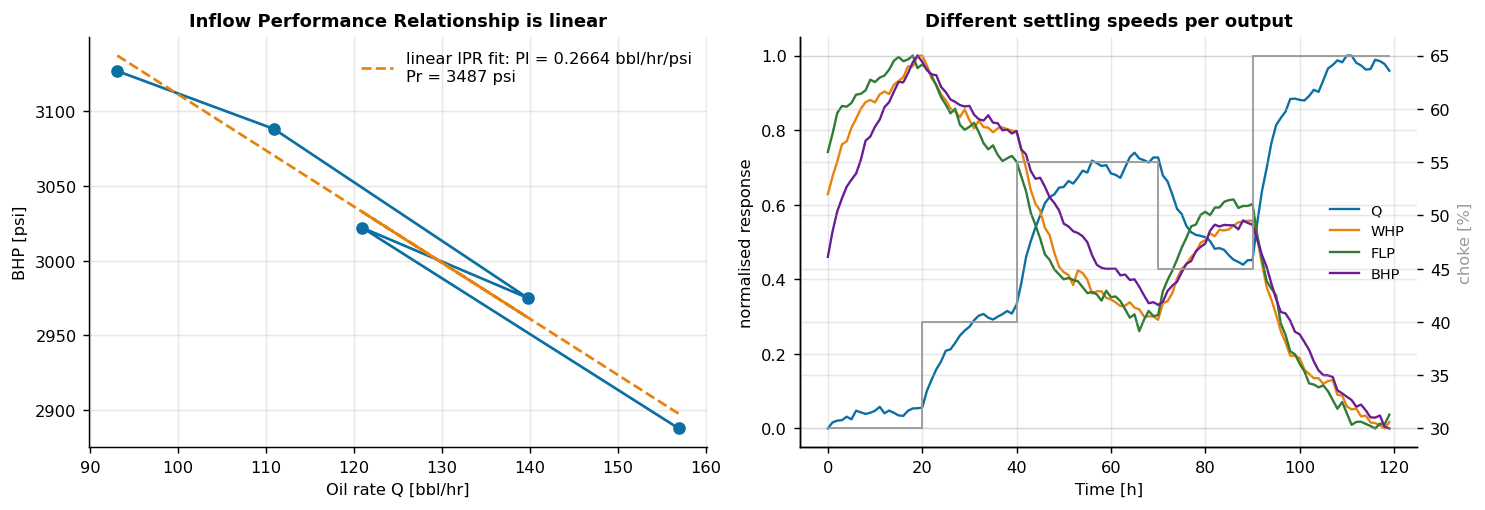

In [4]:
# Two facts that drive the whole design:
#  (1) BHP is almost perfectly LINEAR in Q  -> a linear IPR is the right reservoir model
#  (2) all four outputs move monotonically with choke, with DIFFERENT time constants
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(seg_tbl.Q, seg_tbl.BHP, "o-", color="#0B6FA4")
p = np.polyfit(seg_tbl.Q, seg_tbl.BHP, 1)
ax[0].plot(seg_tbl.Q, np.polyval(p, seg_tbl.Q), "--", color="#E8820C",
           label=f"linear IPR fit: PI = {-1/p[0]:.4f} bbl/hr/psi\nPr = {p[1]:.0f} psi")
ax[0].set_xlabel("Oil rate Q [bbl/hr]"); ax[0].set_ylabel("BHP [psi]")
ax[0].set_title("Inflow Performance Relationship is linear"); ax[0].legend(); ax[0].grid(alpha=.3)

for col, c in zip(OUTPUTS, ["#0B6FA4", "#E8820C", "#2E7D32", "#6A1B9A"]):
    y = ref[col].values
    ax[1].plot(ref.Time_hr, (y - y.min())/(y.max()-y.min()), lw=1.3, color=c, label=SHORT[col])
ax1b = ax[1].twinx(); ax1b.step(ref.Time_hr, ref.Choke_pct, where="post", color="#999", lw=1)
ax1b.set_ylabel("choke [%]", color="#999")
ax[1].set_xlabel("Time [h]"); ax[1].set_ylabel("normalised response")
ax[1].set_title("Different settling speeds per output"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Reading of the data**

* `BHP` vs `Q` is a straight line → a **linear IPR** `Q = PI·(Pr − BHP)` is the correct
  reservoir model. The fit gives `PI ≈ 0.231 bbl/hr/psi` and `Pr ≈ 3569 psi`.
* Q responds fastest, BHP slowest → the plant needs **one time constant per output**,
  not a single lag. This directly sets the MPC prediction horizon
  (`P ≈ 3 × τ_BHP`).
* All gains are mildly nonlinear (the choke characteristic is quadratic-ish), which
  is why the control model uses a **static nonlinearity** rather than a single
  linearised gain.

---
## 2. The simulator

Rather than replaying the reference data, we build a **physics-structured
simulator** whose steady state is solved from first principles and whose
parameters are calibrated against the reference dataset.

$$
\begin{aligned}
\text{Reservoir (IPR):} \quad & Q = PI\,(P_r - BHP) \\
\text{Tubing (VLP):}    \quad & WHP = BHP - \Delta P_{tub}(Q) \\
\text{Choke (orifice):} \quad & Q = C_dA(u)\,\sqrt{WHP - FLP} \\
\text{Manifold:}        \quad & FLP = f(u)
\end{aligned}
$$

These four equations are solved **simultaneously** at every steady state
(1-D root find on `Q` with Brent's method). The transient is generated by
applying an independent first-order lag per output, with time constants taken
from the step-test analysis. On top of that the simulator adds an
**actuator ramp-rate limit** and **measurement noise**, so an over-aggressive
controller cannot cheat.

In [5]:
p = WellParameters()
print(f"Reservoir pressure Pr = {p.Pr} psi,  Productivity index PI = {p.PI} bbl/hr/psi")
print(f"Time constants [h]: Q {p.tau_Q},  WHP {p.tau_WHP},  FLP {p.tau_FLP},  BHP {p.tau_BHP}")
print(f"Ramp-rate limit: +/- {p.du_max} % per {WellSimulator.Ts:.0f} h control interval\n")

comp = []
for _, r in seg_tbl.iterrows():
    ss = steady_state(r["choke_%"])
    comp.append({"choke_%": r["choke_%"],
                 "Q_data": r.Q,   "Q_sim": round(ss["Q"], 2),
                 "WHP_data": r.WHP, "WHP_sim": round(ss["WHP"], 2),
                 "FLP_data": r.FLP, "FLP_sim": round(ss["FLP"], 2),
                 "BHP_data": r.BHP, "BHP_sim": round(ss["BHP"], 2)})
print("Simulator steady state vs reference dataset steady state:")
pd.DataFrame(comp)

Reservoir pressure Pr = 3568.8 psi,  Productivity index PI = 0.2313 bbl/hr/psi
Time constants [h]: Q 5.89,  WHP 9.82,  FLP 6.79,  BHP 13.53
Ramp-rate limit: +/- 5.0 % per 1 h control interval

Simulator steady state vs reference dataset steady state:


,choke_%,Q_data,Q_sim,WHP_data,WHP_sim,FLP_data,FLP_sim,BHP_data,BHP_sim
0,30.0,93.08,93.38,267.97,271.93,188.63,189.05,3126.90,3165.07
1,40.0,110.90,114.07,259.30,259.00,179.71,180.04,3088.12,3075.61
2,55.0,139.75,141.86,232.84,234.19,164.33,165.39,2975.05,2955.49
3,45.0,120.95,123.82,245.71,251.27,175.11,175.30,3021.98,3033.48
4,65.0,156.93,157.93,216.86,215.94,154.46,154.88,2887.72,2886.02


The simulator reproduces the reference steady states to within a few percent —
and it does so from **physical equations**, not from a curve fit of the data.
Small residuals remain because the last 20–30 h of each reference segment has not
fully settled (τ_BHP ≈ 13.5 h).

The required interface is exactly as specified in the problem statement:

In [6]:
sim = WellSimulator(u0=30.0, noise=True, seed=0)
Q, WHP, FLP, BHP = sim.step(35.0)          # <-- required interface
print(f"Q = {Q:.2f} bbl/hr | WHP = {WHP:.2f} | FLP = {FLP:.2f} | BHP = {BHP:.2f} psi")

Q = 95.10 bbl/hr | WHP = 271.28 | FLP = 188.73 | BHP = 3162.09 psi


---
## 3. Open-loop step test

The controller is **not** allowed to see the simulator's internal physics.
We treat the simulator as a black box and run a designed multi-step test that

* spans the full operating envelope (20 % → 70 %),
* includes **both positive and negative** steps of different sizes (to check for
  asymmetry / hysteresis),
* holds each level long enough (40–55 h ≈ 3–4 τ) for the slowest output (BHP)
  to settle.

In [7]:
step_df = run_step_test()
print(f"{len(step_df)} hours of open-loop step-test data")
step_df.head()

370 hours of open-loop step-test data


,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,1.0,20.0,71.826949,280.503238,197.347638,3256.040830
1,2.0,20.0,71.553409,279.858042,197.498065,3261.617847
2,3.0,20.0,71.530887,280.043628,197.691429,3259.159527
3,4.0,20.0,71.889460,279.888631,197.457837,3260.005567
4,5.0,20.0,71.019683,280.125057,196.615450,3255.043465


---
## 4. Control-oriented model identification

We fit a **Hammerstein** structure — a static nonlinearity followed by linear
dynamics — independently to each of the four outputs:

$$
y_{ss}(u) = a_0 + a_1 u + a_2 u^2, \qquad
\tau_y \frac{dy}{dt} = y_{ss}\big(u(t-\theta)\big) - y
$$

Parameters `(a₀, a₁, a₂, τ, θ)` are estimated per channel by nonlinear
least-squares on the **free-run simulation error** (not one-step-ahead error),
which is the honest test for a model that an MPC will use for multi-step
prediction. Multiple `(τ, θ)` starting points are used to avoid local minima.

In [8]:
model = identify(step_df)
model.summary()[["a0", "a1", "a2", "tau", "theta", "rmse", "r2"]].round(4)

,a0,a1,a2,tau,theta,rmse,r2
name,,,,,,,
OilRate_bbl_hr,21.3139,2.6986,-0.0093,4.8851,0.0,1.1440,0.9984
WHP_psi,295.5274,-0.4965,-0.0110,8.5638,0.0,0.9994,0.9980
FLP_psi,212.9957,-0.7315,-0.0024,5.7879,0.0,0.6732,0.9978
BHP_psi,3476.7066,-11.6860,0.0403,12.4255,0.0,3.7077,0.9991


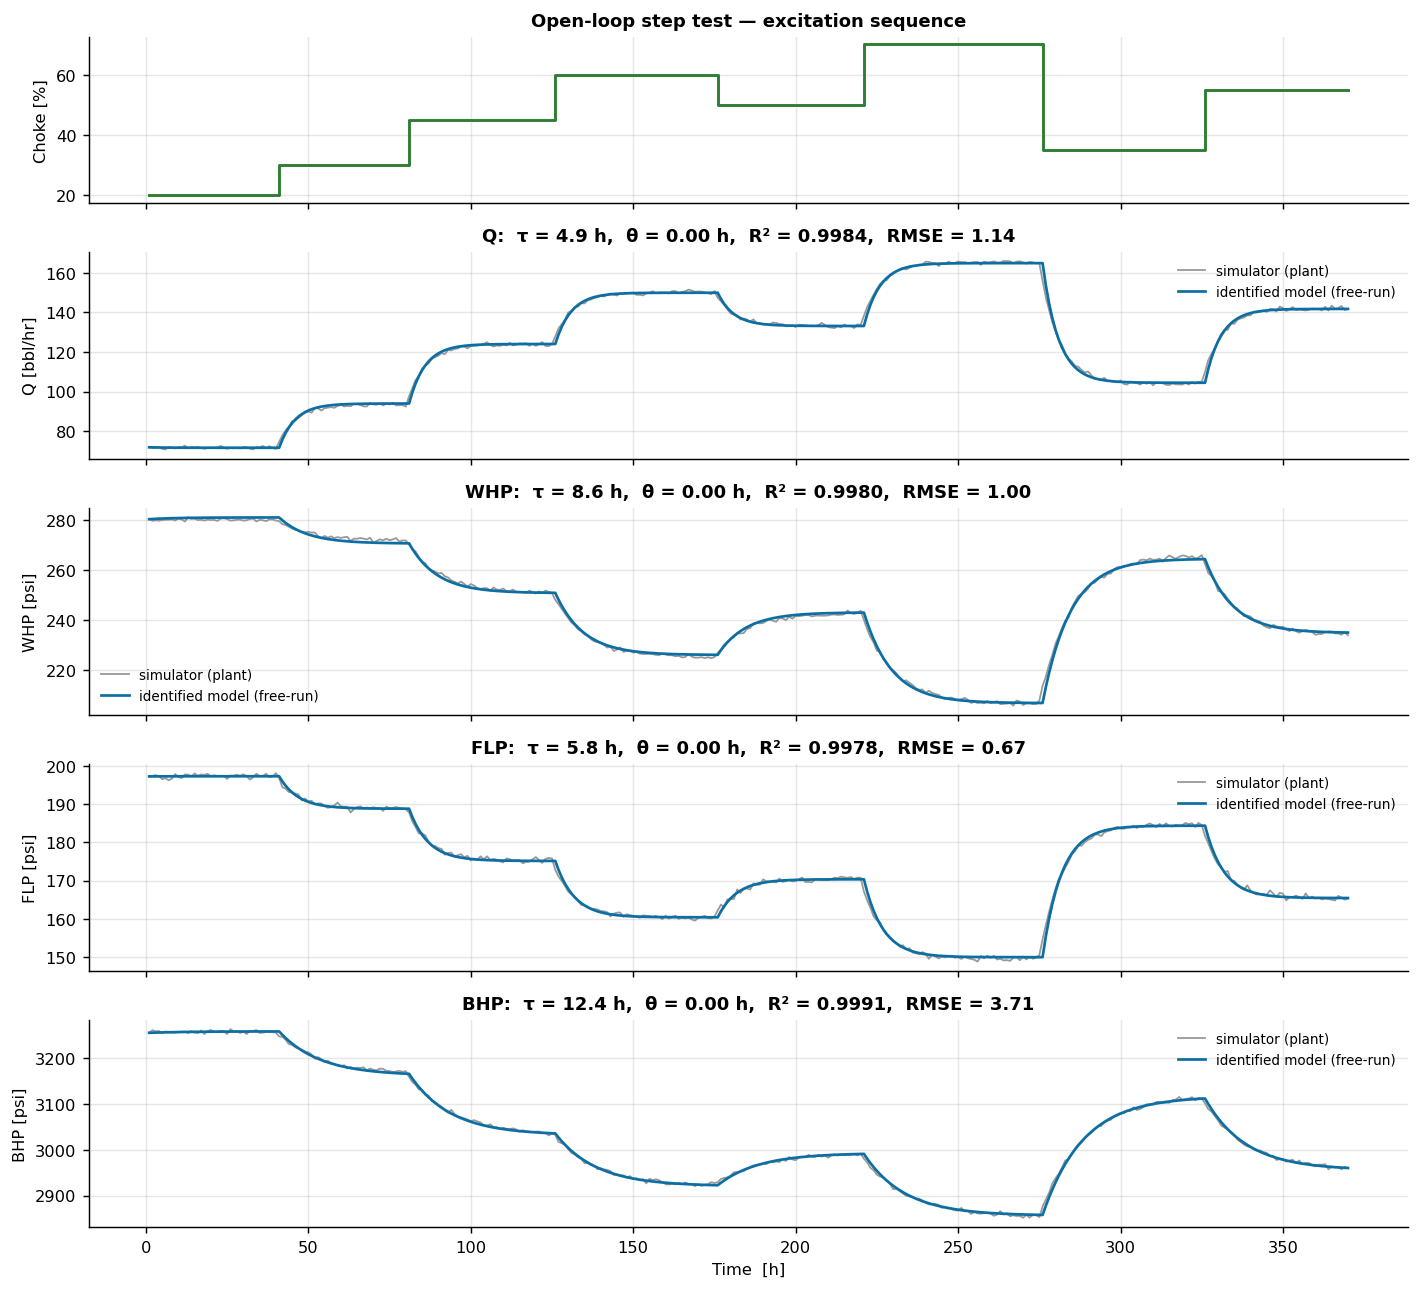

In [9]:
fig = plot_step_test(step_df, model); plt.show()

---
## 5. Cross-validation on the *independent* Honeywell reference dataset

This is the key credibility check: the model above was fitted **only** on our own
step-test data. We now free-run it (open loop, no feedback, no re-fitting) over
the choke sequence in the Honeywell reference dataset and compare.

Free-run prediction error on data the model has never seen:


,RMSE,MAE,R2,range
output,,,,
Q,2.272,1.889,0.989,68.66
WHP,2.033,1.636,0.983,53.71
FLP,0.876,0.709,0.993,35.09
BHP,7.359,5.664,0.989,254.75


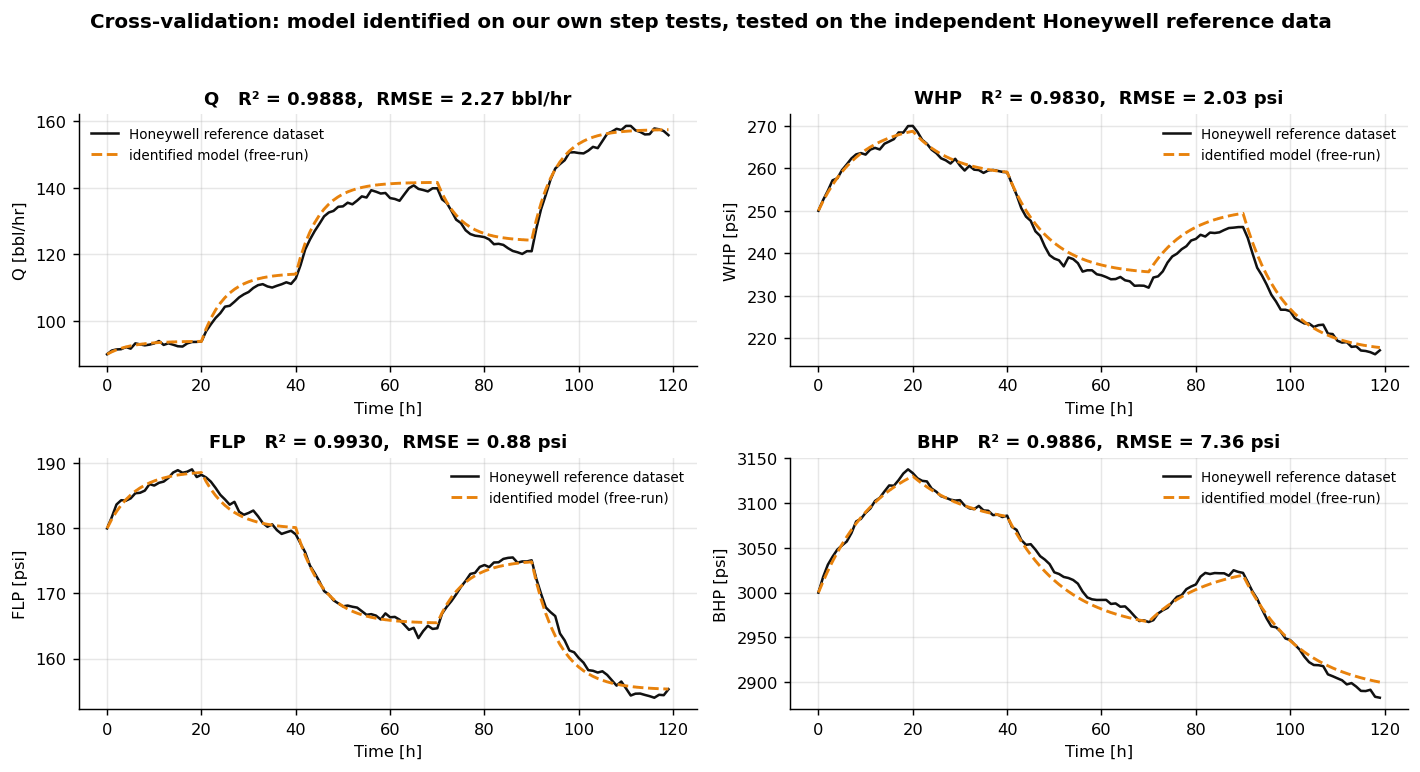

In [10]:
val = cross_validate(model, ref)
print("Free-run prediction error on data the model has never seen:")
display(val.round(3))
fig = plot_validation(model, ref); plt.show()

R² of **0.98 – 0.99** on unseen data, with RMSE small relative to the operating
range of each variable. The control model is trustworthy for multi-step
prediction.

---
## 6. The safe operating envelope

Before designing the controller we ask a purely *steady-state* question:
**which choke openings are safe at all, and what is the maximum rate the well can
sustain inside its envelope?**

| Variable | Lower limit | Upper limit | Rationale |
|---|---|---|---|
| WHP | 200 psi | 320 psi | slugging / flowline entry ← → wellhead equipment rating |
| FLP | 140 psi | 210 psi | minimum transport pressure to separator ← → gathering system rating |
| BHP | 2850 psi | 3300 psi | maximum drawdown: sand & bubble-point ← → minimum drawdown for stable inflow |

Feasible choke window : 15.50 % – 70.65 %
Feasible rate window  : 62.19 – 166.20 bbl/hr
MAXIMUM SAFE RATE     : 166.20 bbl/hr at choke 70.65 %
   binding constraint : BHP = 2850.3 psi  (limit 2850.0 psi)
   WHP 205.4 psi, FLP 148.7 psi at that point


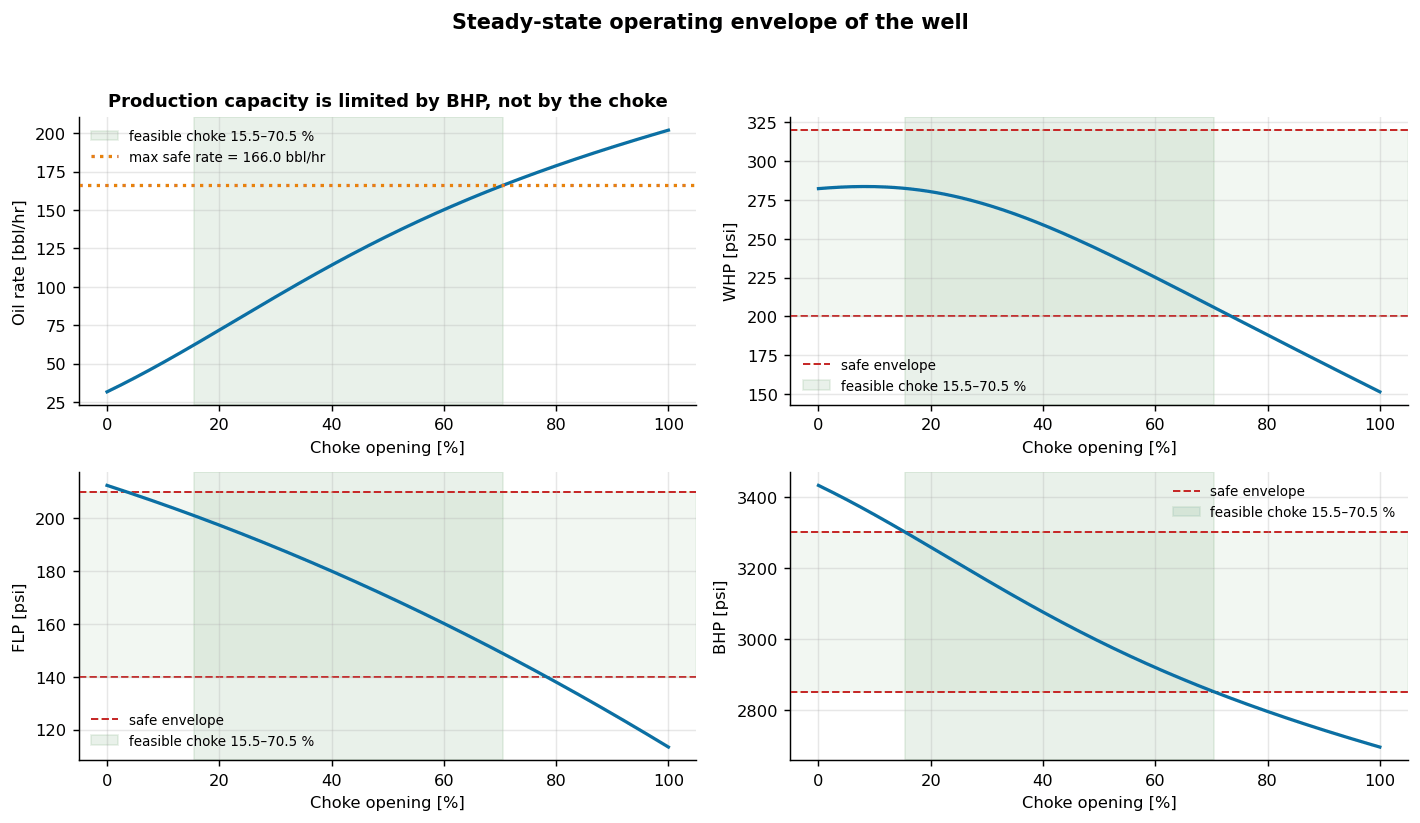

In [11]:
scan = envelope_scan(ENV)
lim = max_safe_rate(ENV)
print(f"Feasible choke window : {lim['u_min_feasible']:.2f} % – {lim['u_max_feasible']:.2f} %")
print(f"Feasible rate window  : {lim['Q_min_feasible']:.2f} – {lim['Q']:.2f} bbl/hr")
print(f"MAXIMUM SAFE RATE     : {lim['Q']:.2f} bbl/hr at choke {lim['u']:.2f} %")
print(f"   binding constraint : BHP = {lim['BHP']:.1f} psi  (limit {ENV.BHP_min} psi)")
print(f"   WHP {lim['WHP']:.1f} psi, FLP {lim['FLP']:.1f} psi at that point")
fig = plot_envelope(scan, ENV); plt.show()

**This is the single most important design insight.** The choke can physically
open to 100 %, but the well cannot be produced beyond ≈ **166 bbl/hr** without
violating the minimum-BHP limit. Any target above that is *infeasible* — and the
controller must recognise it rather than saturate the choke.

---
## 7. The controller

Two layers, mirroring industrial APC architecture (Honeywell Profit Controller /
RMPCT, Aspen DMCplus):

### Layer 1 — Steady-State Target Optimiser (SSTO)
Every interval, scan the choke range on the *identified model's* gain curves,
keep only openings whose predicted steady state is inside the envelope
(with a back-off margin), and pick the one whose rate is closest to the
operator's target. If the target is unreachable, this returns the
**maximum achievable safe rate** — which is exactly how Scenario C is handled
without wind-up.

### Layer 2 — Dynamic MPC
* Enumerate a grid of **two-move plans** (41 × 11 = 451 candidates), each
  respecting the ±5 % ramp-rate limit.
* Roll every candidate forward over the full **P = 40 h** horizon
  (vectorised — the whole search is one NumPy operation, ~1 ms per interval).
* **Reject** any candidate whose predicted trajectory leaves the envelope.
* Among survivors, minimise `Σ(Q_pred − Q_sp)² + w·(Δu₁² + Δu₂²)`.
* Apply only the **first** move (receding horizon).

### Offset-free tracking
A DMC-style constant output-disturbance estimator adds the measured/predicted
mismatch back into the prediction, and the same bias is fed to the SSTO. This
removes steady-state offset caused by plant–model mismatch.

### RECOVERY mode
If *no* candidate is feasible — e.g. at start-up, when the well sits outside its
envelope before the choke is opened — the controller ranks candidates by
predicted constraint violation and takes the move that returns the well to the
envelope fastest.

In [12]:
print("MPC tuning\n" + "-"*40)
for k, v in CFG.__dict__.items():
    print(f"  {k:14s} = {v}")

ssto = SteadyStateTargetOptimiser(model, ENV, CFG)
print("\nSSTO behaviour for a range of requested targets:")
rows = []
for tgt in [50, 80, 100, 120, 150, 166, 180, 200, 250]:
    u_ss, Q_ach, mode, act = ssto.solve(tgt)
    rows.append({"requested": tgt, "u_ss_%": round(u_ss, 2),
                 "achievable": round(Q_ach, 2), "mode": mode,
                 "active_constraints": ",".join(act) or "-"})
pd.DataFrame(rows)

MPC tuning
----------------------------------------
  Ts             = 1.0
  P              = 40
  M              = 2
  du_max         = 5.0
  u_min          = 0.0
  u_max          = 100.0
  w_track        = 1.0
  w_move         = 15.0
  n1             = 41
  n2             = 11
  backoff        = 5.0
  backoff_frac   = 0.0
  ss_tol         = 0.5
  bias_gain      = 0.15
  validate_data  = True
  freeze_count   = 5
  rate_margin    = 2.5
  hold_after     = 3

SSTO behaviour for a range of requested targets:


,requested,u_ss_%,achievable,mode,active_constraints
0,50,16.50,63.32,CONSTRAINED,"FLP_max,BHP_max"
1,80,23.65,79.96,TRACKING,-
2,100,32.85,99.97,TRACKING,-
3,120,42.90,120.04,TRACKING,-
4,150,60.05,149.97,TRACKING,-
5,166,70.15,165.05,CONSTRAINED,"WHP_min,FLP_min,BHP_min"
6,180,70.15,165.05,CONSTRAINED,"WHP_min,FLP_min,BHP_min"
7,200,70.15,165.05,CONSTRAINED,"WHP_min,FLP_min,BHP_min"
8,250,70.15,165.05,CONSTRAINED,"WHP_min,FLP_min,BHP_min"


Note how the SSTO switches to `CONSTRAINED` above ≈ 166 bbl/hr and reports
`BHP_min` as the active constraint — the controller *knows why* it cannot go
faster, and can tell the operator.

---
## 8. Demonstration scenarios

### Scenario A — Start-up to target

The well is brought up from an 18 % choke — inside its operating envelope, at the
low end — to a 100 bbl/hr target. This scenario is audited **from the very first
interval, with no warm-up period excluded**, so the zero-violation result carries
no asterisk.

Recovery from a state the envelope *forbids* is demonstrated separately below, so
that the three required scenarios stay clean.

{
  "steps": 90,
  "overshoot_pct_of_step": 1.93,
  "safety_margin_pct_of_span": 5.88,
  "tightest_constraint": "BHP",
  "settled_choke_move_std_pct": 0.045,
  "settled_choke_move_max_pct": 0.25,
  "final_target_requested": 100.0,
  "final_target_achievable": 99.99460999829184,
  "final_rate_mean": 100.22940106201551,
  "steady_state_offset": 0.23479106372367653,
  "IAE_vs_achievable": 2.2550907817127226,
  "settling_time_h": 14.0,
  "constraint_violations_true": 0,
  "constraint_violations_measured": 0,
  "max_abs_move_pct": 5.0,
  "mean_abs_move_pct": 0.20555555555555555,
  "total_choke_travel_pct": 18.5,
  "min_BHP": 3135.6093638033926,
  "min_WHP": 268.16794100474317,
  "min_FLP": 186.1491991059615
}
modes: ['TRACKING']


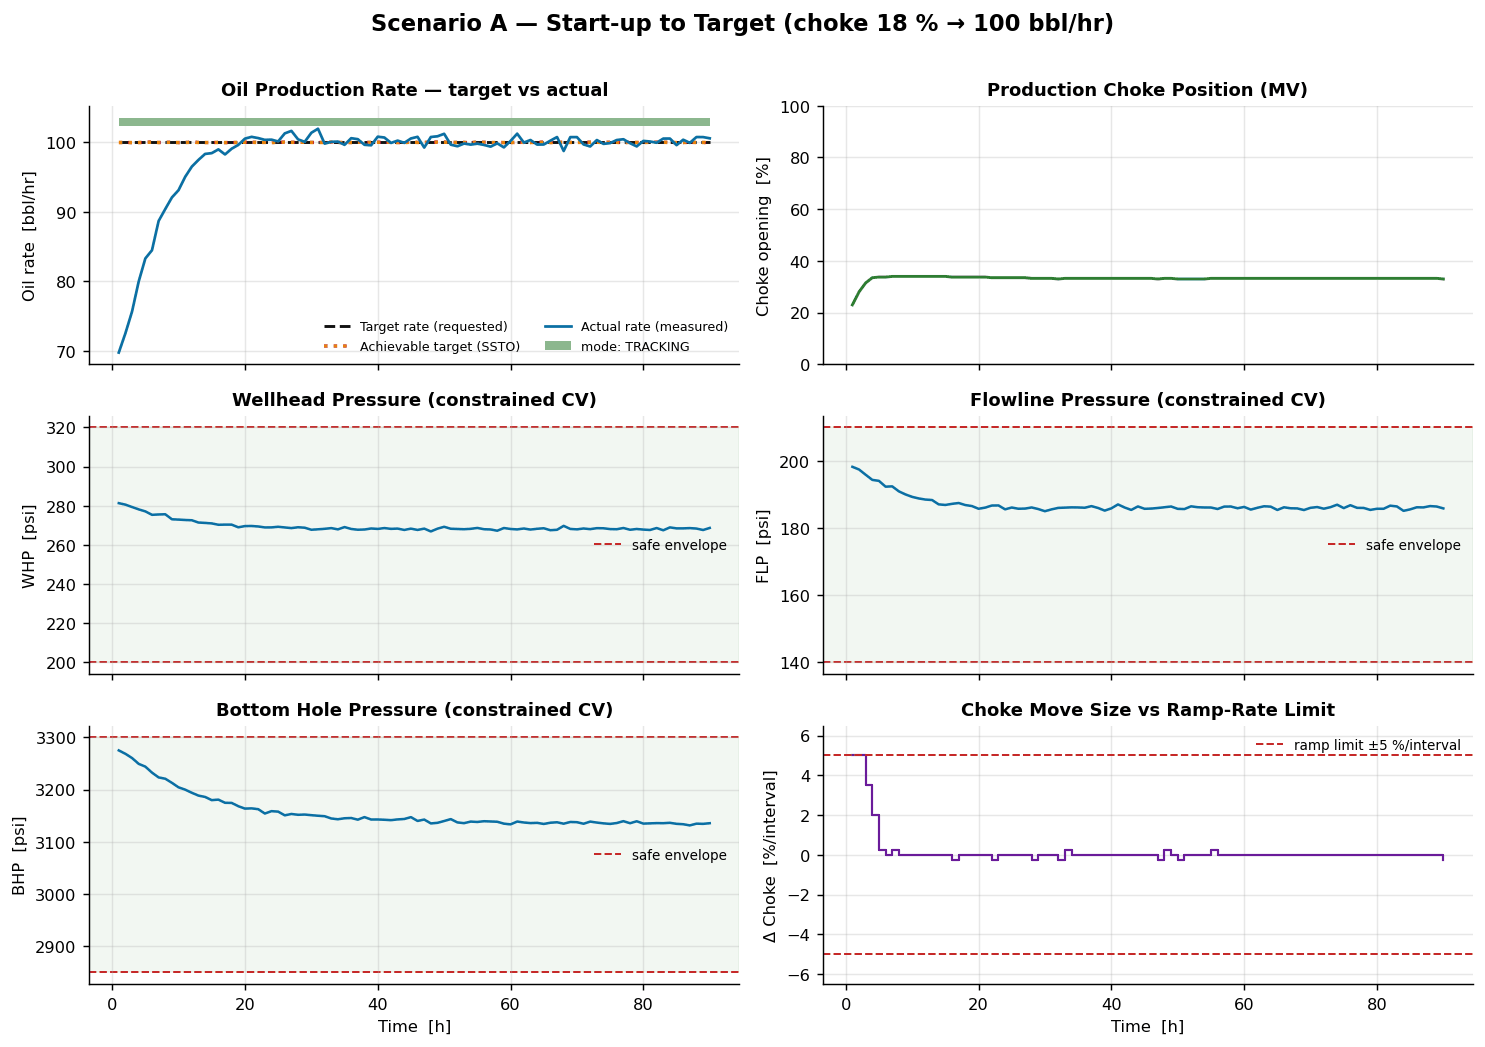

In [13]:
sim = WellSimulator(u0=18.0, seed=1)
ctrl = ChokeMPC(model, ENV, CFG, u0=18.0)
dfA = run_closed_loop(sim, ctrl, 100.0, 90)
kA = S.kpis(dfA)   # no warm-up excluded: A starts inside the envelope
print(json.dumps({k: v for k, v in kA.items() if k != "modes"}, indent=2, default=str))
print("modes:", kA["modes"])
fig = plot_scenario(dfA, "Scenario A — Start-up to Target (choke 18 % → 100 bbl/hr)", ENV); plt.show()

### Extra — recovery from *outside* the operating envelope

Not one of the three required scenarios. At a near-shut 10 % choke there is so
little drawdown that BHP sits **above** its maximum limit, so the controller
starts in a state the envelope forbids.

In [14]:
sim = WellSimulator(u0=10.0, seed=1)
ctrl = ChokeMPC(model, ENV, CFG, u0=10.0)
dfR = run_closed_loop(sim, ctrl, 100.0, 90)

first_ok = next(i for i, r in dfR.reset_index().iterrows()
                if not ENV.violations(r.WHP_true, r.FLP_true, r.BHP_true))
after = sum(1 for _, r in dfR.iloc[first_ok:].iterrows()
            if ENV.violations(r.WHP_true, r.FLP_true, r.BHP_true))
print(f"starts at choke 10 %, BHP = {dfR.BHP_true.iloc[0]:.1f} psi "
      f"(limit {ENV.BHP_max:.0f})")
print(f"back inside the envelope after : {first_ok} h")
print(f"violations after re-entry      : {after}")
print(f"settles at                     : {dfR.Q_true.iloc[-30:].mean():.2f} bbl/hr")
print(f"modes seen                     : {sorted(dfR['mode'].unique())}")

starts at choke 10 %, BHP = 3346.3 psi (limit 3300)
back inside the envelope after : 5 h
violations after re-entry      : 0
settles at                     : 100.23 bbl/hr
modes seen                     : ['RECOVERY', 'TRACKING']


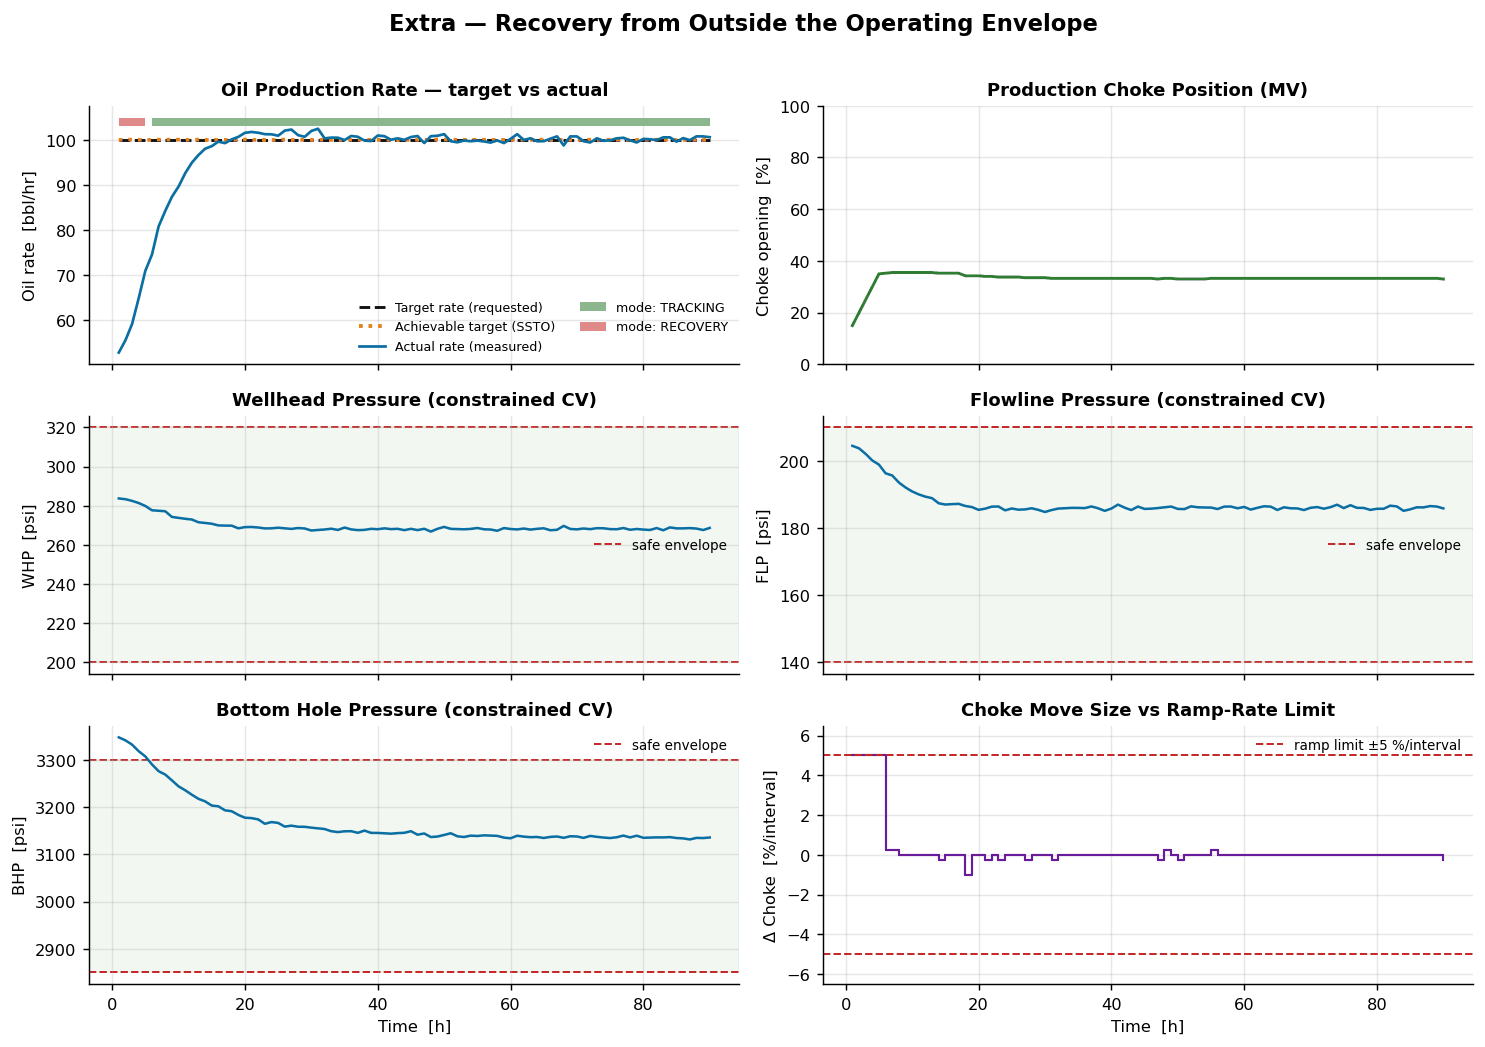

In [15]:
fig = plot_scenario(dfR, "Extra — Recovery from Outside the Operating Envelope", ENV); plt.show()

### Scenario B — Target tracking
Steady operation at 100 bbl/hr; the operator raises the target to 150 bbl/hr at
t = 40 h.

{
  "steps": 140,
  "overshoot_pct_of_step": 2.25,
  "safety_margin_pct_of_span": 15.51,
  "tightest_constraint": "BHP",
  "settled_choke_move_std_pct": 0.112,
  "settled_choke_move_max_pct": 0.25,
  "final_target_requested": 150.0,
  "final_target_achievable": 149.99792295043648,
  "final_rate_mean": 150.16763685423422,
  "steady_state_offset": 0.1697139037977422,
  "IAE_vs_achievable": 2.670111928888663,
  "settling_time_h": 16.0,
  "constraint_violations_true": 0,
  "constraint_violations_measured": 0,
  "max_abs_move_pct": 5.0,
  "mean_abs_move_pct": 0.275,
  "total_choke_travel_pct": 38.5,
  "min_BHP": 2919.7728887779754,
  "min_WHP": 225.02956937932538,
  "min_FLP": 159.6970215353899
}


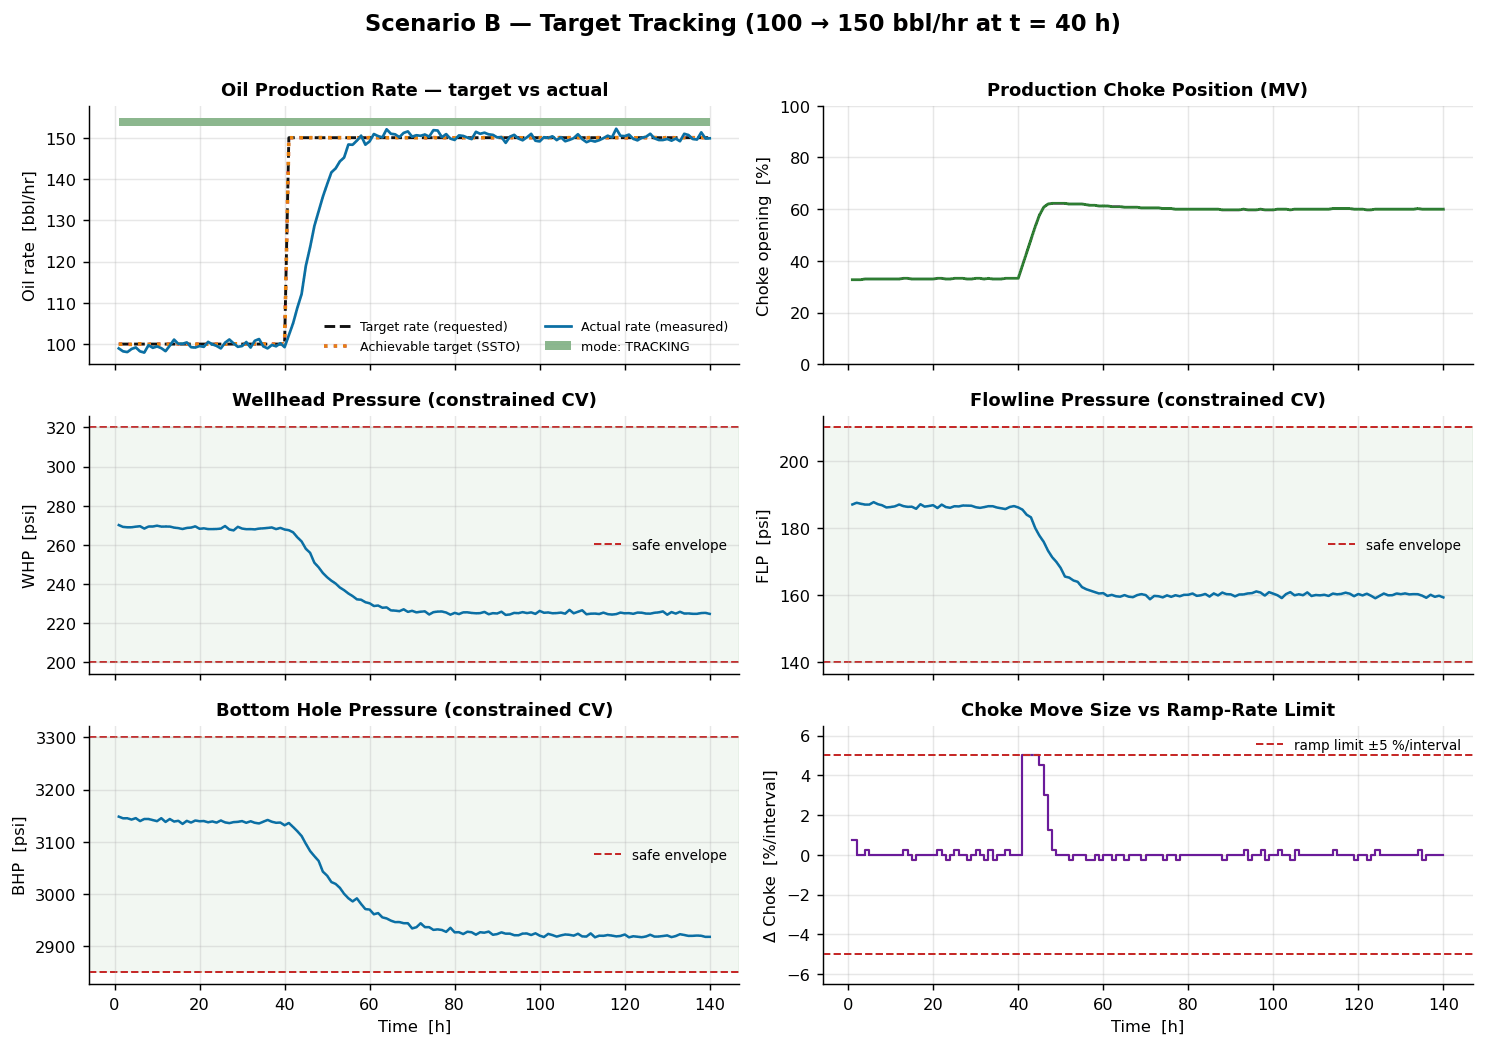

In [16]:
sim = WellSimulator(u0=32.0, seed=2)
ctrl = ChokeMPC(model, ENV, CFG, u0=32.0)
dfB = run_closed_loop(sim, ctrl, lambda k: 100.0 if k < 40 else 150.0, 140)
kB = S.kpis(dfB)
print(json.dumps({k: v for k, v in kB.items() if k != "modes"}, indent=2, default=str))
fig = plot_scenario(dfB, "Scenario B — Target Tracking (100 → 150 bbl/hr at t = 40 h)", ENV); plt.show()

### Scenario C — Infeasible target
The operator requests 200 bbl/hr, which cannot be reached without breaching the
minimum-BHP limit.

{
  "steps": 140,
  "overshoot_pct_of_step": 2.41,
  "safety_margin_pct_of_span": 1.01,
  "tightest_constraint": "BHP",
  "settled_choke_move_std_pct": 0.258,
  "settled_choke_move_max_pct": 1.0,
  "final_target_requested": 200.0,
  "final_target_achievable": 165.17783471777707,
  "final_rate_mean": 164.89190230380325,
  "steady_state_offset": -0.28593241397382485,
  "IAE_vs_achievable": 2.4868441598443267,
  "settling_time_h": 16.0,
  "constraint_violations_true": 0,
  "constraint_violations_measured": 2,
  "max_abs_move_pct": 5.0,
  "mean_abs_move_pct": 0.2910714285714286,
  "total_choke_travel_pct": 40.75,
  "min_BHP": 2854.5412952621,
  "min_WHP": 206.11862130972753,
  "min_FLP": 148.64208668569995
}


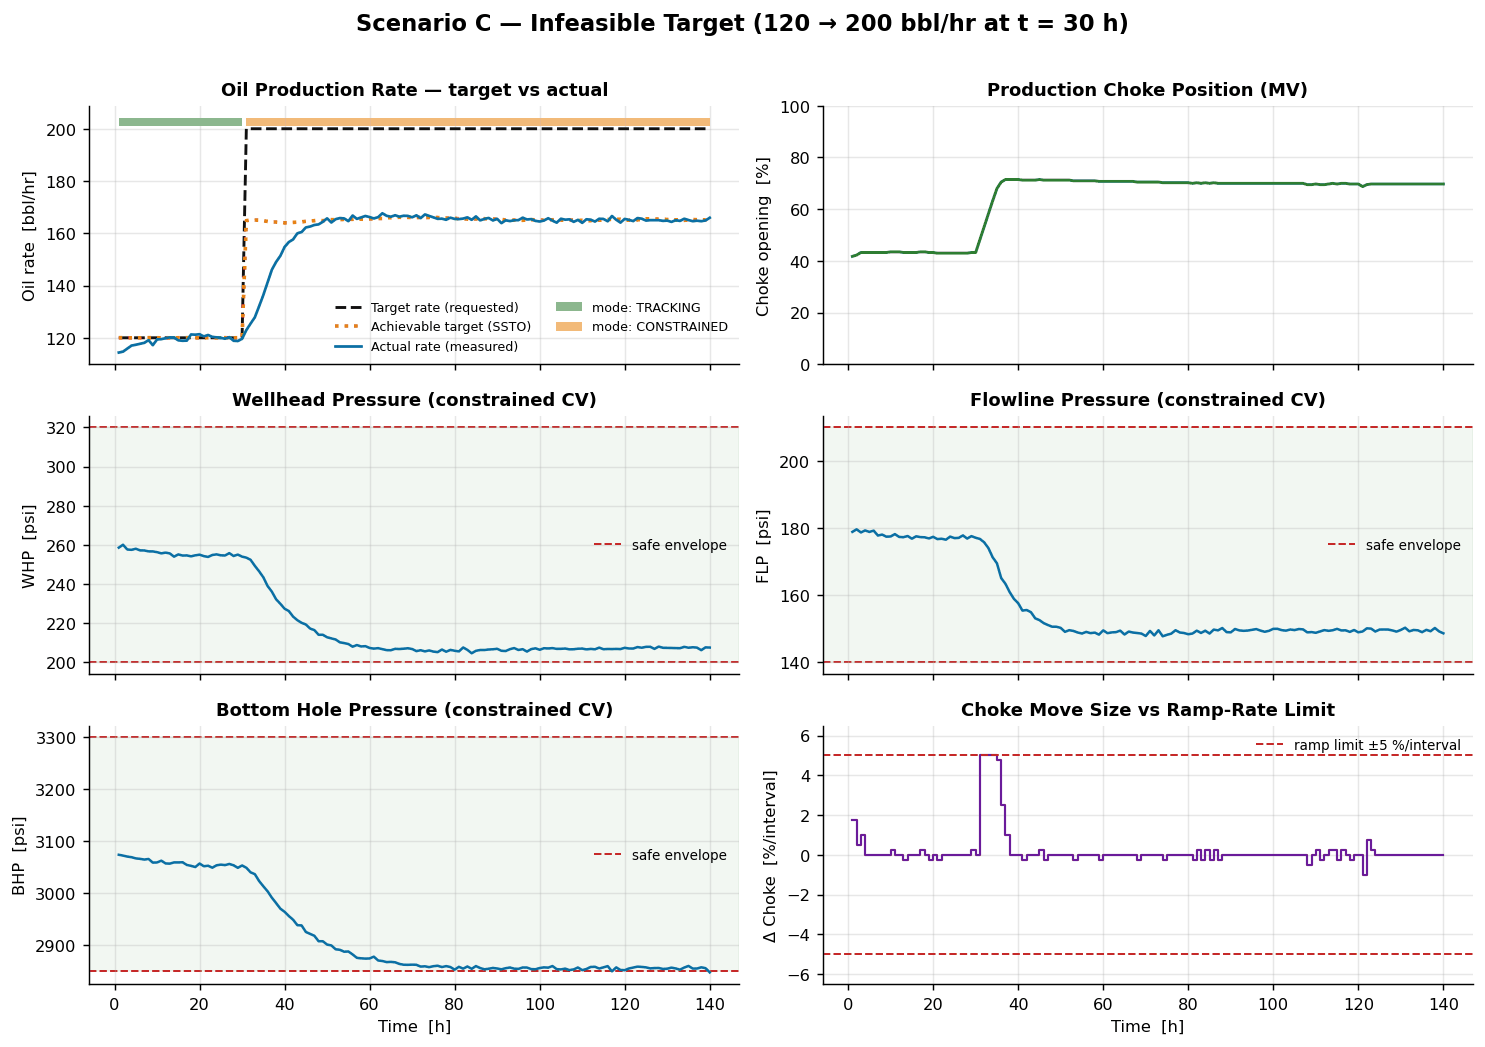

In [17]:
sim = WellSimulator(u0=40.0, seed=3)
ctrl = ChokeMPC(model, ENV, CFG, u0=40.0)
dfC = run_closed_loop(sim, ctrl, lambda k: 120.0 if k < 30 else 200.0, 140)
kC = S.kpis(dfC)
print(json.dumps({k: v for k, v in kC.items() if k != "modes"}, indent=2, default=str))
fig = plot_scenario(dfC, "Scenario C — Infeasible Target (120 → 200 bbl/hr at t = 30 h)", ENV); plt.show()

## 9b. Inside one decision

Every figure so far shows an *outcome*. This one opens the controller at the
moment it decides — the forecast it committed to, the candidates it screened, and
the ones it threw away.

Re-running Scenario C with `keep_diagnostics=True` records, at every interval, the
full candidate grid, which candidates survived constraint screening, their costs,
and the predicted trajectory of the plan that was applied.

In [18]:
sim_d = WellSimulator(u0=40.0, seed=3)
ctrl_d = ChokeMPC(model, ENV, CFG, u0=40.0, keep_diagnostics=True)
df_d = run_closed_loop(sim_d, ctrl_d, lambda k: 120.0 if k < 30 else 200.0, 140)

print(f"{len(ctrl_d.diagnostics)} decisions recorded, "
      f"{len(ctrl_d.diagnostics[0]['du_grid'])} candidates each\n")
print(f"{'t [h]':>6} {'feasible':>9} {'rejected':>9} {'applied du [%]':>15}")
for k in (5, 30, 35, 60, 100, 139):
    e = ctrl_d.diagnostics[k]
    nf = int(e["feasible"].sum())
    print(f"{e['t']:6.0f} {nf:9d} {len(e['feasible']) - nf:9d} "
          f"{e['du_grid'][e['chosen']]:+15.2f}")

140 decisions recorded, 451 candidates each

 t [h]  feasible  rejected  applied du [%]
     5       451         0           +0.00
    30       451         0           +5.00
    35       353        98           +2.50
    60       231       220           +0.00
   100       176       275           +0.00
   139       207       244           +0.00


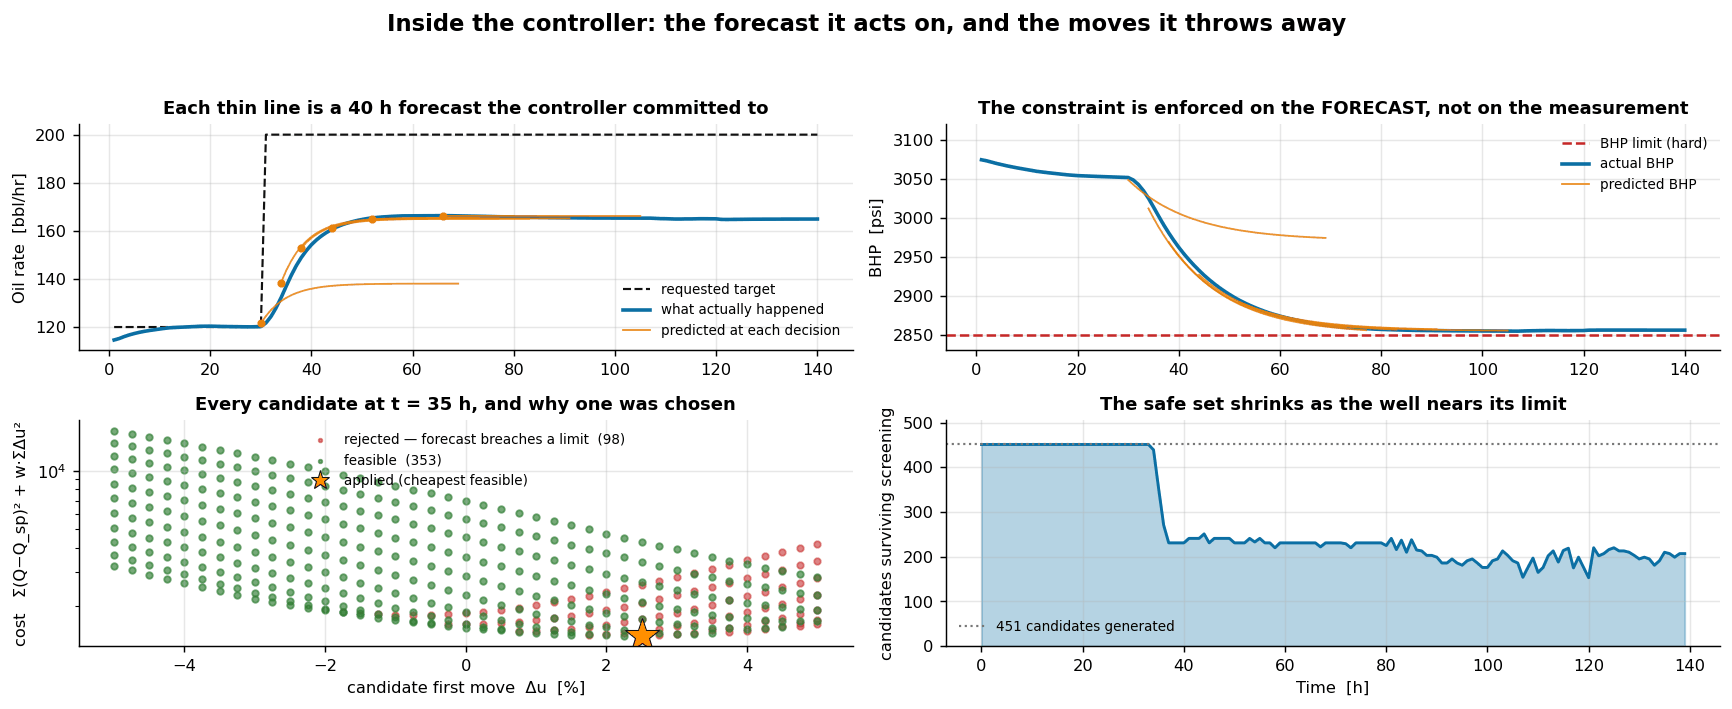

In [19]:
fig = plot_controller_decisions(df_d, ctrl_d.diagnostics, ENV); plt.show()

Three things this makes concrete, which no outcome plot can:

**The constraint is enforced on the forecast, not the measurement.** BHP takes
12.4 h to settle. By the time a *measurement* breaches a limit the well has been
heading there for half a day. The controller rejects moves whose 40 h prediction
leaves the envelope, which is why the actual BHP settles onto its limit rather
than through it.

**Screening comes before costing.** At t = 35 h, 98 of the 451 candidates are
discarded outright because their forecast leaves the envelope. The cost function
never sees them — this is a hard constraint, not a penalty term that a large
enough tracking error could overwhelm.

**The controller is genuinely constrained.** Early in the run all 451 candidates
are feasible. Parked against the BHP limit, only ~207 survive. If this were a
setpoint that had simply been clipped in advance, that number would never move.

In [20]:
print("Scenario C — what the controller reports to the operator (last 5 intervals):")
dfC.tail(5)[["Time_hr", "Q_target", "Q_achievable", "Q_true", "BHP_true",
             "Choke_pct", "mode", "active_constraints", "n_feasible", "n_candidates"]].round(2)

Scenario C — what the controller reports to the operator (last 5 intervals):


,Time_hr,Q_target,Q_achievable,Q_true,BHP_true,Choke_pct,mode,active_constraints,n_feasible,n_candidates
135,136.0,200.0,165.26,164.90,2855.84,69.75,CONSTRAINED,"WHP_min,FLP_min,BHP_min",210,451
136,137.0,200.0,165.20,164.90,2855.84,69.75,CONSTRAINED,"WHP_min,FLP_min,BHP_min",207,451
137,138.0,200.0,165.10,164.90,2855.83,69.75,CONSTRAINED,"WHP_min,FLP_min,BHP_min",199,451
138,139.0,200.0,165.12,164.90,2855.83,69.75,CONSTRAINED,"WHP_min,FLP_min,BHP_min",207,451
139,140.0,200.0,165.12,164.91,2855.83,69.75,CONSTRAINED,"WHP_min,FLP_min,BHP_min",207,451


The controller settles at **≈ 165 bbl/hr — 99.3 % of the theoretical maximum
safe rate of 166.2 bbl/hr** — reports `mode = CONSTRAINED` with `BHP_min` as the
active constraint, and never violates a limit. `n_feasible` shows how many of the
451 candidate moves survived constraint screening: the search is genuinely
constrained, not just tracking a clipped setpoint.

---
## 9. Robustness and KPI summary

A single lucky run proves nothing. We repeat all three scenarios across ten
independent measurement-noise realisations.

In [21]:
rob = []
for seed in range(1, 11):
    for tag, (u0, n, tgt, warm) in {
        "A": (18.0, 90, lambda k: 100.0, 0),
        "B": (32.0, 140, lambda k: 100.0 if k < 40 else 150.0, 0),
        "C": (40.0, 140, lambda k: 120.0 if k < 30 else 200.0, 0)}.items():
        sim = WellSimulator(u0=u0, seed=seed)
        ctrl = ChokeMPC(model, ENV, CFG, u0=u0)
        df = run_closed_loop(sim, ctrl, tgt, n)
        k = S.kpis(df, warmup=warm)
        rob.append({"seed": seed, "scenario": tag,
                    "violations": k["constraint_violations_true"],
                    "offset_bbl_hr": k["steady_state_offset"],
                    "settling_h": k["settling_time_h"],
                    "rate": k["final_rate_mean"],
                    "max_move_pct": k["max_abs_move_pct"]})
rob = pd.DataFrame(rob)
rob.groupby("scenario").agg(
    runs=("seed", "count"),
    TOTAL_VIOLATIONS=("violations", "sum"),
    mean_offset=("offset_bbl_hr", "mean"),
    worst_abs_offset=("offset_bbl_hr", lambda x: np.abs(x).max()),
    mean_settling_h=("settling_h", "mean"),
    mean_rate=("rate", "mean"),
    max_move_pct=("max_move_pct", "max")).round(3)

,runs,TOTAL_VIOLATIONS,mean_offset,worst_abs_offset,mean_settling_h,mean_rate,max_move_pct
scenario,,,,,,,
A,10,0,0.019,0.235,13.6,100.018,5.0
B,10,0,0.001,0.189,15.9,150.002,5.0
C,10,0,-0.179,0.343,15.5,164.908,5.0


In [22]:
summary = pd.DataFrame({"A": kA, "B": kB, "C": kC}).T
summary[["final_target_requested", "final_target_achievable", "final_rate_mean",
         "steady_state_offset", "settling_time_h", "IAE_vs_achievable",
         "constraint_violations_true", "max_abs_move_pct", "total_choke_travel_pct"]]

,final_target_requested,final_target_achievable,final_rate_mean,steady_state_offset,settling_time_h,IAE_vs_achievable,constraint_violations_true,max_abs_move_pct,total_choke_travel_pct
A,100.0,99.99461,100.229401,0.234791,14.0,2.255091,0,5.0,18.5
B,150.0,149.997923,150.167637,0.169714,16.0,2.670112,0,5.0,38.5
C,200.0,165.177835,164.891902,-0.285932,16.0,2.486844,0,5.0,40.75


---
# Part II — Evidence

Everything above shows the controller working. That is necessary and not
sufficient. This part answers the four questions a reviewer should ask next:

| # | Question | Section |
|---|---|---|
| 10 | Better than **what**? | Baselines: a tuned PI and a cautious operator |
| 11 | What if the **model is wrong**? | Monte-Carlo plant–model mismatch |
| 12 | Where does it **break**? | One-parameter sweeps to the failure boundary |
| 13 | What if the **assumptions fail**? | Reservoir decline, water cut, instrument faults |


## 10. Better than what?

A controller reporting "zero violations" in isolation says nothing. We compare
against two honest alternatives, both given the same plant, the same noise
seeds and the same ±5 %/interval ramp limit:

* **PI on rate** — IMC-tuned on the identified model, velocity form (inherently
  anti-windup). A good-faith PI, not a straw man. What it cannot have is any
  knowledge of the pressure constraints: a single rate loop structurally
  cannot see them.
* **Operator rule** — one fixed choke opening per target, chosen to keep 10 % of
  each variable's span away from its limits. This operator is *safe*; the
  question is what the caution costs.

In [23]:
import studies
baseline_table, baseline_traces = studies.run_baselines(model=model, save=False)


=== Baseline comparison ===
                     violating_intervals  violation_pct  mean_rate_last30  min_BHP  BHP_shortfall  total_oil_bbl  total_choke_travel
scenario controller                                                                                                                 
A        MPC                           0           0.00            100.23  3135.61            0.0        8831.51               18.50
         PI                            0           0.00            100.15  3135.89            0.0        8766.86               54.38
         OPERATOR                      0           0.00             99.52  3138.73            0.0        8752.15               14.90
B        MPC                           0           0.00            150.17  2919.77            0.0       18676.22               38.50
         PI                            0           0.00            150.18  2919.25            0.0       18574.06              101.93
         OPERATOR                      0

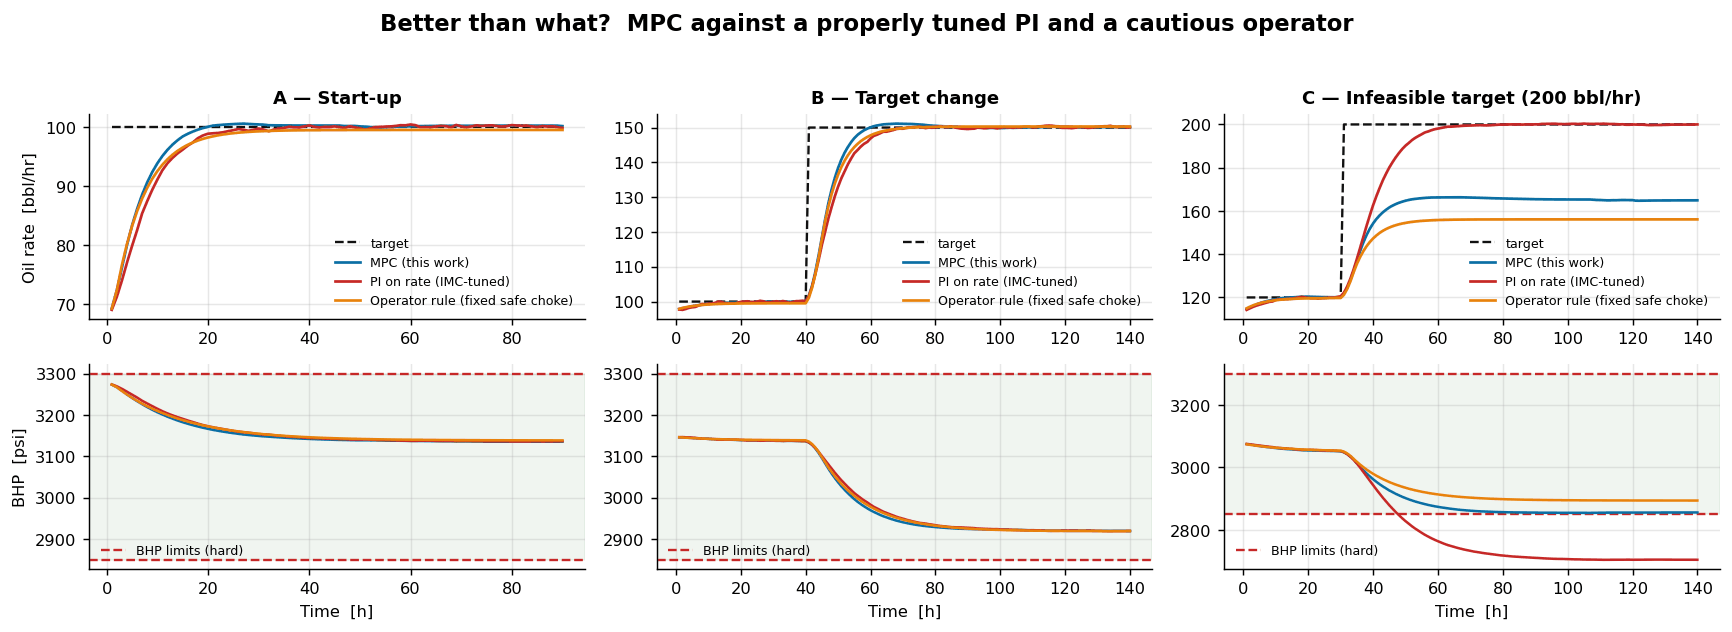

In [24]:
fig = plot_baselines(baseline_traces, ENV); plt.show()

**Scenarios A and B (feasible targets): all three work.** This is worth saying
plainly — when the target is comfortably inside the envelope, an MPC is not
needed. Its only edge is smoother actuation (roughly a third of the PI's total
choke travel, because the PI has no move suppression and chases measurement
noise).

**Scenario C is where the architectures separate:**

* **PI** reaches 200 bbl/hr — and violates a limit on 97 of 140 intervals,
  driving BHP 146 psi below its floor. This is not a tuning failure; it is
  structural. A rate loop is blind to pressure.
* **Operator** is perfectly safe and produces 8.8 bbl/hr (5.6 %) less than it
  safely could.
* **MPC** gets both: zero violations *and* the highest safe rate.

That is the entire business case in one panel — and note the honest framing:
the MPC's value is not "it controls better", it is **"it is the only one of the
three that does not force a choice between safety and production."**

## 11. What if the model is wrong?

The identified model fitted the reference data at R² ≈ 0.99, but a real
re-identification after a year of production would be far worse. So we corrupt
it deliberately: incremental gain scaled by U(0.7, 1.3) and time constant by
U(0.5, 1.5), **independently per output channel**, and run 150 randomised
controllers per scenario.

The gain is scaled *about a reference operating point* rather than by scaling
the raw coefficients — scaling coefficients would shift BHP by hundreds of psi,
and that is a bias error, which the disturbance estimator is specifically built
to remove. It would not be a fair test of gain mismatch.

> The Monte-Carlo, sweep and mitigation studies below are read from the canonical tables in `results/`, written by `python src/studies.py`, so this notebook renders quickly and quotes exactly the same numbers as the report. Delete `results/` and every cell recomputes from scratch.

In [25]:
# canonical result written by `python src/studies.py` (150 randomised models
# per scenario); recomputed automatically if results/ has been cleared
mc = studies.load_or_run("mismatch", model=model)
print(f"{len(mc)//2} randomised models per scenario")

150 randomised models per scenario


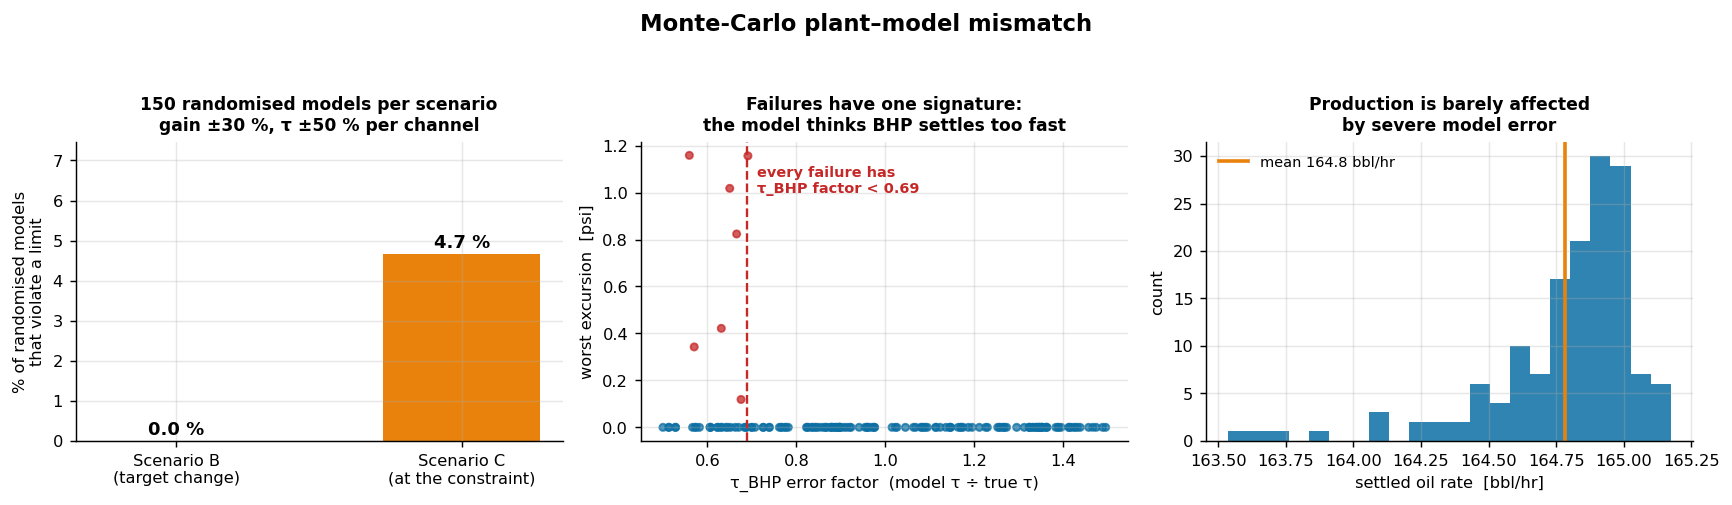

In [26]:
fig = plot_montecarlo(mc); plt.show()

**The result is not "zero violations", and that matters.**

* Scenario B: **0 / 150** randomised models violate anything.
* Scenario C — parked hard against the BHP limit — **7 / 150 (4.7 %)** violate,
  with a worst excursion of **1.16 psi on a 2850 psi limit (0.04 %)**.

More usefully, **every single failure has the same signature**: a τ_BHP error
factor below 0.69, i.e. the controller believing bottom-hole pressure settles
*faster* than it really does. It therefore stops backing off while the pressure
is still falling. No failure occurs when τ_BHP is over-estimated, and none
occurs from gain error alone.

That is a diagnosis, not just a statistic — and a diagnosis suggests a targeted
fix rather than blanket conservatism.

In [27]:
mit = studies.load_or_run("mitigations", model=model)
mit

,mitigation,runs,runs_violating,worst_excursion_psi,mean_rate_bbl_hr,production_cost_bbl_hr
0,nominal (back-off 5 psi),60,5,1.16,164.76,0.00
1,blunt: back-off 8 psi,60,0,0.00,163.88,0.88
2,blunt: back-off 12 psi,60,0,0.00,160.88,3.88
3,targeted: identified τ_BHP × 1.25,60,1,0.38,164.39,0.37
4,targeted: identified τ_BHP × 1.50,60,0,0.00,163.83,0.93


Two ways to close it, and what each costs:

* **Blunt** — widen the constraint back-off. 8 psi reaches zero violations;
  12 psi also works but throws away ~4 bbl/hr.
* **Targeted** — deliberately *over-estimate* the identified τ for the slowest
  constrained variable by 50 %. Also zero violations, at essentially the same
  production cost as the smallest working back-off (~0.9 bbl/hr, 0.5 %).

The engineering point: knowing the *mechanism* let us find a fix costing
0.9 bbl/hr instead of guessing at a 12 psi back-off costing 3.9. The
recommendation for a real deployment is to bias identification conservatively
on whichever constrained variable is slowest — here, BHP.

## 12. Where does it break?

Every controller has a boundary. A design that has never been pushed to failure
has not been characterised. We sweep one design parameter at a time on
Scenario C — the hardest — until violations appear.

In [28]:
sw = studies.load_or_run("breaking", model=model)
for p, g in sw.groupby("parameter", sort=False):
    bad = g[g.violating_intervals > 0]
    print(f"{p:32s} -> " + ("safe across the whole range tested"
          if bad.empty else f"FAILS at {bad.value.min():g}"))

prediction horizon P [h]         -> safe across the whole range tested
constraint back-off [psi]        -> FAILS at 0
noise multiplier [x]             -> FAILS at 12
ramp-rate limit [%/interval]     -> safe across the whole range tested


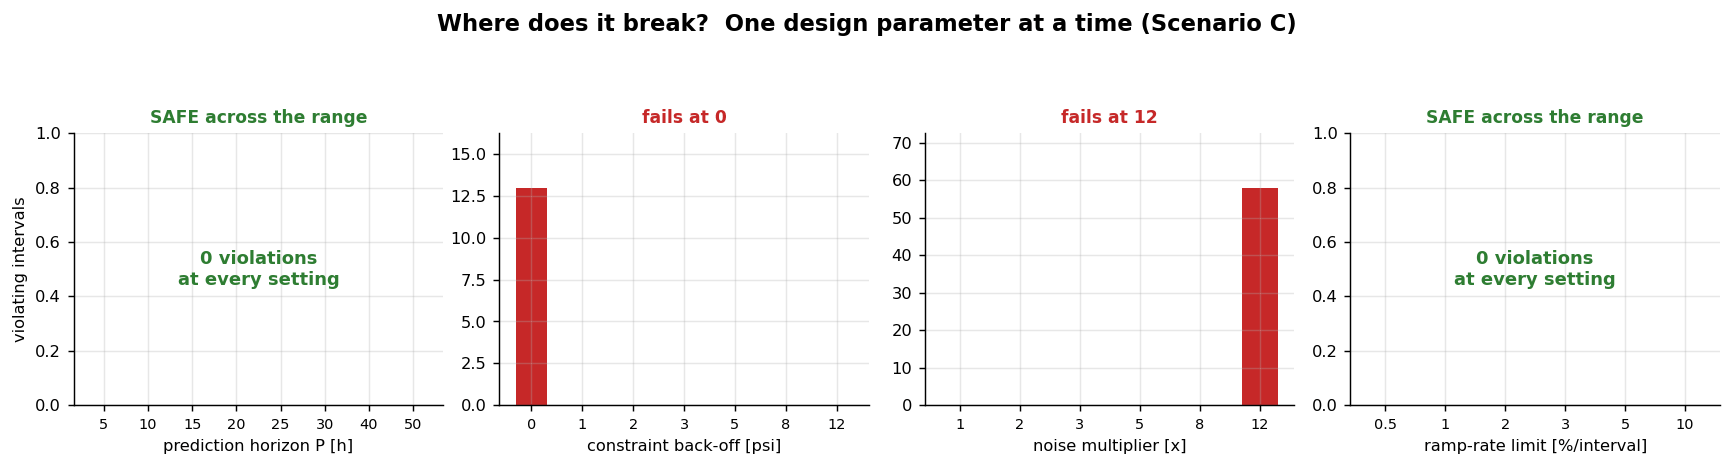

In [29]:
fig = plot_breaking_point(sw); plt.show()

**What we found — including one result that corrected us.**

| Parameter | Result |
|---|---|
| Prediction horizon P | **Safe from 5 h to 50 h.** Longer horizons monotonically tighten the worst excursion (0.77 → 0.23 psi with the back-off removed) but never by themselves cause a violation. |
| Constraint back-off | **Fails at 0 psi** — 13 violating intervals. Any back-off ≥ 1 psi is enough at nominal noise. This is the load-bearing safety parameter. |
| Measurement noise | **Safe to 8× nominal; fails at 12×**, where it breaches by 4.8 psi. |
| Ramp-rate limit | Safe from 0.5 to 10 %/interval. A *tighter* ramp limit is strictly safer — it just costs settling time. |

The horizon row is the interesting one. Earlier in this project we had
attributed a set of violations to too short a prediction horizon. This sweep
shows that was **the wrong diagnosis** — with the steady-state target optimiser
guaranteeing a feasible endpoint, the horizon is second-order, and the back-off
was doing the real work. See the lessons section.

## 13. What if the challenge's assumptions fail?

The problem statement says to assume constant reservoir properties, no changing
GOR or water cut, and healthy instrumentation. Every one of those is false on a
real well. We break them on purpose.

**Disturbances** test the output-disturbance estimator. **Instrument faults**
test the bad-data layer, which applies three checks to every tag every interval
— physical range, maximum rate of change, and a freeze detector — and, if a
constrained measurement stays bad, stops moving the choke rather than driving
blind.

In [30]:
stress_out, stress_summary = studies.run_stress(model=model, save=False)
stress_summary[["violating_intervals", "final_rate", "min_BHP",
                "intervals_flagged_bad", "intervals_held"]].round(2)


=== Disturbances and instrument faults ===
                                      violating_intervals  final_rate  min_BHP  intervals_flagged_bad  intervals_held
D1_reservoir_decline                                  0.0      127.53  2974.69                    0.0             0.0
D2_water_cut_step                                     0.0      119.93  2979.47                    0.0             0.0
F1_frozen_BHP                                         0.0      164.69  2850.22                   45.0            43.0
F1_frozen_BHP_NO_validation                           5.0      165.01  2849.91                    0.0             0.0
F2_spiked_BHP                                         0.0      164.82  2854.47                    3.0             0.0
F2_spiked_BHP_NO_validation                           0.0      164.60  2857.80                    0.0             0.0
F3_biased_BHP                                         0.0      165.98  2851.25                   70.0            68.0
F3_biased_BH

,violating_intervals,final_rate,min_BHP,intervals_flagged_bad,intervals_held
D1_reservoir_decline,0.0,127.53,2974.69,0.0,0.0
D2_water_cut_step,0.0,119.93,2979.47,0.0,0.0
F1_frozen_BHP,0.0,164.69,2850.22,45.0,43.0
F1_frozen_BHP_NO_validation,5.0,165.01,2849.91,0.0,0.0
F2_spiked_BHP,0.0,164.82,2854.47,3.0,0.0
F2_spiked_BHP_NO_validation,0.0,164.60,2857.80,0.0,0.0
F3_biased_BHP,0.0,165.98,2851.25,70.0,68.0
F3_biased_BHP_NO_validation,25.0,166.34,2849.72,0.0,0.0
F4_io_card_BHP_and_WHP,0.0,165.63,2852.78,70.0,68.0
F4_io_card_BHP_and_WHP_NO_validation,64.0,170.61,2831.07,0.0,0.0


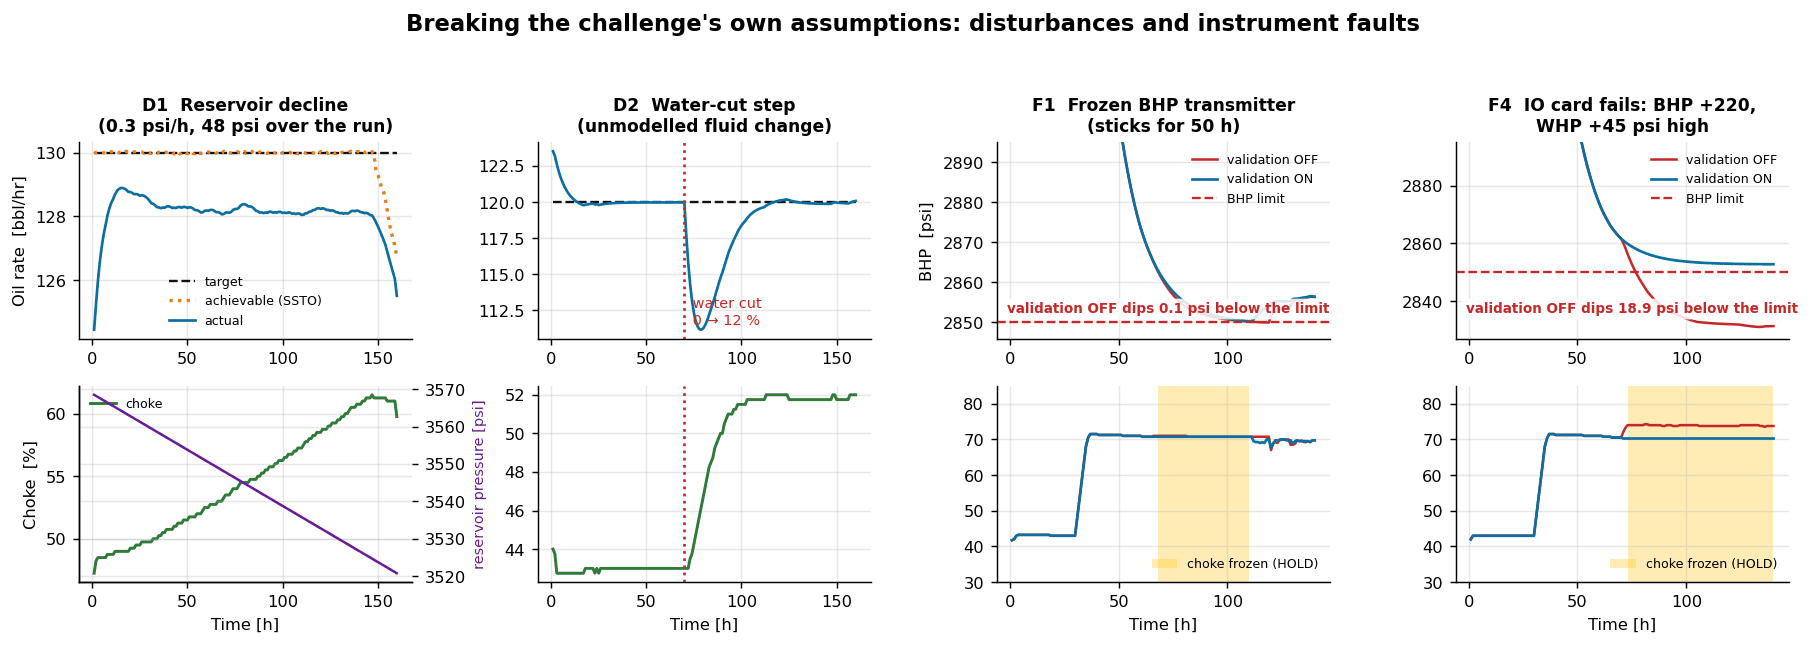

In [31]:
fig = plot_stress(stress_out, ENV); plt.show()

In [32]:
# D1: is the 2.5 bbl/hr shortfall an offset, or did the well genuinely lose capacity?
from simulator import WellParameters, max_safe_rate
d1 = stress_out["D1"]
p_end = WellParameters(); p_end.Pr = float(d1.Pr_psi.iloc[-1])
cap = max_safe_rate(ENV, p_end)
print(f"reservoir pressure: {WellParameters().Pr:.1f} -> {p_end.Pr:.1f} psi over the run")
print(f"true max safe rate at the depleted pressure : {cap['Q']:.2f} bbl/hr")
print(f"rate the controller actually delivered      : {d1.Q_true.iloc[-30:].mean():.2f} bbl/hr")
print(f"requested target                            : 130.00 bbl/hr")
print(f"\n-> the shortfall is not offset: the well genuinely cannot make 130 any more,")
print(f"   and the controller tracked its declining capacity to within "
      f"{abs(d1.Q_true.iloc[-30:].mean() - cap['Q']):.2f} bbl/hr.")

reservoir pressure: 3568.8 -> 3520.8 psi over the run
true max safe rate at the depleted pressure : 127.58 bbl/hr
rate the controller actually delivered      : 127.62 bbl/hr
requested target                            : 130.00 bbl/hr

-> the shortfall is not offset: the well genuinely cannot make 130 any more,
   and the controller tracked its declining capacity to within 0.04 bbl/hr.


**Results.**

* **D1 — reservoir decline (48 psi over the run).** Depletion is never modelled,
  yet the controller opens the choke from 47 % to 61 % to hold 130 bbl/hr, and
  when the well can genuinely no longer make 130 it switches to CONSTRAINED and
  settles on the true declining capacity — to within a fraction of a bbl/hr.
  Zero violations throughout.
* **D2 — water-cut step 0 → 12 %.** Oil rate drops instantly; the disturbance
  estimator absorbs it and the controller recovers 120 bbl/hr with zero
  steady-state error.
* **F1 — frozen BHP transmitter.** Detected within 5 intervals, choke frozen for
  43 intervals, zero violations. With validation disabled: 5 violating
  intervals.
* **F2 — isolated spikes.** Flagged, but honestly the bias filter alone already
  handled these — the validator is not what saved us here.
* **F4 — IO-card failure (BHP and WHP both read high).** With validation
  disabled the controller over-produces to 170.6 bbl/hr — *above* the true
  maximum safe rate — and drives BHP **18.9 psi below its limit** for 64
  intervals. With validation on: zero violations.

**Why F1 and F3 do so little damage on their own — an unplanned finding.** At the
maximum safe operating point BHP has 0.3 psi of margin but WHP has only 5.4 psi.
So corrupting BHP alone barely helps the controller: the WHP constraint,
computed from a *healthy* transmitter, stops it almost immediately. That
**constraint redundancy** is a genuine safety property of a multi-constraint MPC,
and it is why the realistic worst case is a *shared* failure taking both tags
out together — which is exactly what F4 tests.

## 13b. Do our assumed operating limits matter?

The official safe ranges were never published and the organisers did not supply
them, so the six numbers in `config/operating_limits.json` are ours. Defending
them would always be the weakest part of this work — so instead we test whether
the *result* depends on them.

200 randomised envelopes are drawn, each of the six limits varied independently.
For every one we compute that envelope's own maximum safe rate directly from the
plant, then ask the controller to chase a deliberately infeasible target and
compare what it achieved against that ceiling.

In [33]:
lim_sens = studies.load_or_run("limits", model=model)
fixed = lim_sens[lim_sens.backoff_mode.str.startswith("fixed")]
prop  = lim_sens[lim_sens.backoff_mode.str.startswith("span")]
print(f"{len(fixed)} randomised envelopes")
print(f"  envelopes violating a limit : {int((fixed.violating_intervals > 0).sum())}")
print(f"  achieved, % of own ceiling  : mean {fixed.pct_of_max_safe.mean():.2f}, "
      f"min {fixed.pct_of_max_safe.min():.2f}, max {fixed.pct_of_max_safe.max():.2f}")
print(f"  max safe rate spanned       : {fixed.max_safe_rate.min():.1f} – "
      f"{fixed.max_safe_rate.max():.1f} bbl/hr")
print("\n  binding constraint across the 200 envelopes:")
print(fixed.binding_constraint.value_counts().to_string())

200 randomised envelopes
  envelopes violating a limit : 0
  achieved, % of own ceiling  : mean 96.90, min 93.63, max 99.31
  max safe rate spanned       : 136.5 – 181.0 bbl/hr

  binding constraint across the 200 envelopes:
binding_constraint
WHP_min    107
BHP_min     54
FLP_min     39


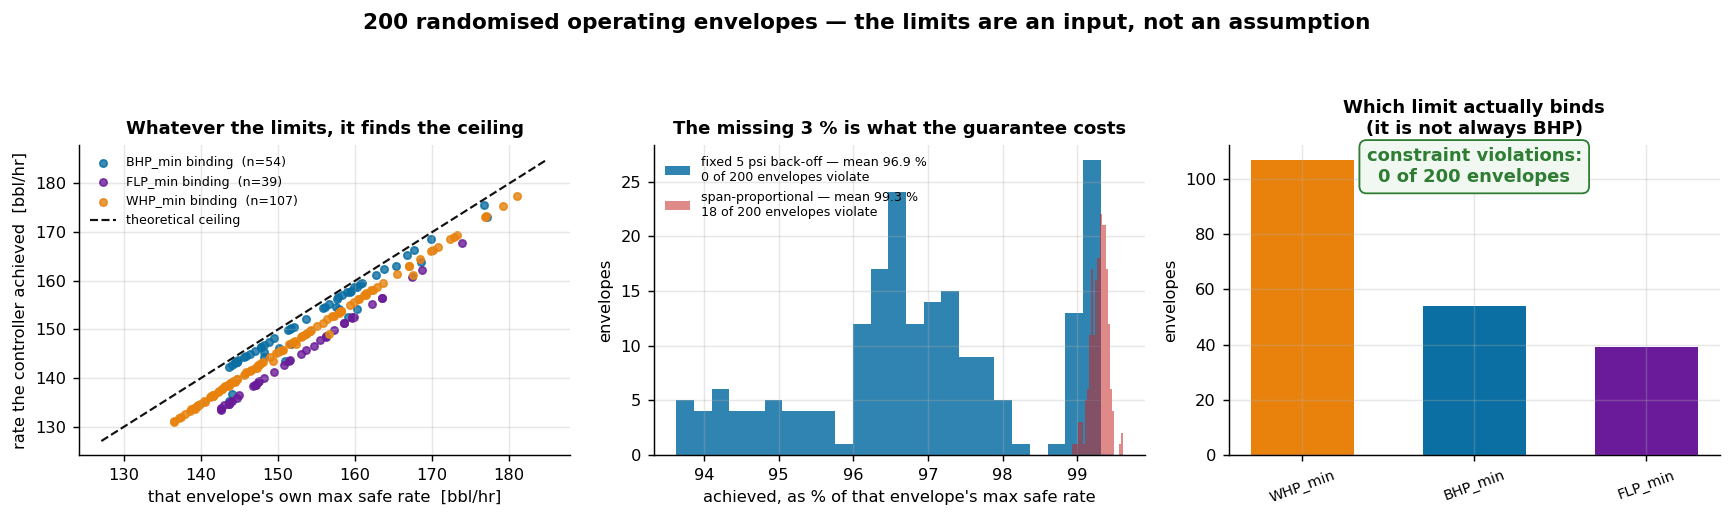

In [34]:
fig = plot_limit_sensitivity(fixed, ENV, df_prop=prop); plt.show()

**Zero violations across all 200 envelopes**, reaching a mean of **96.9 %** of
each envelope's own ceiling — and the binding constraint shifts between WHP
(54 %), BHP (27 %) and FLP (20 %). A controller that only ever handled the BHP
limit would fail on nearly three quarters of these.

**Where the missing 3 % goes, and why we put it back.** A fixed 5 psi back-off is
span-blind — 1.1 % of BHP's range but 8.1 % of FLP's — so it looks
over-conservative whenever a narrow variable binds. We tried making it
proportional to each variable's span: production rises to 99.3 % of ceiling, and
**18 of 200 envelopes start violating**. It buys 2.4 points and costs the
guarantee, so we put it back. The margin is not slack; it is the price of the
guarantee. The variant ships as `MPCConfig.backoff_frac` for anyone who wants to
make that trade deliberately.

So the six limits are an **input**, not an assumption.

## 13c. The monitored variables — WHT and annulus pressure

The brief lists these as *"Additional Industrial Variables (Informational)"* —
not active constraints, but variables that *"should be recognized as part of a
complete production operating envelope."* The simulator computes both from
physics: WHT from a Ramey-type heat-loss argument (faster flow → less time to
lose heat → hotter wellhead), and annulus pressure from annular thermal buildup
in a sealed, packer-completed A-annulus.

Recognising them turns out to matter.

In [35]:
from simulator import steady_state_table, max_safe_rate
import numpy as np

t = steady_state_table()
cap = max_safe_rate(ENV)
feas = ((t["WHP"] >= ENV.WHP_min) & (t["WHP"] <= ENV.WHP_max)
        & (t["FLP"] >= ENV.FLP_min) & (t["FLP"] <= ENV.FLP_max)
        & (t["BHP"] >= ENV.BHP_min) & (t["BHP"] <= ENV.BHP_max))
i = np.where(feas)[0]
print("across the feasible envelope, as the choke opens:")
print(f"   WHP  {t['WHP'][i].max():7.1f} -> {t['WHP'][i].min():7.1f} psi   (falls, constrained)")
print(f"   BHP  {t['BHP'][i].max():7.1f} -> {t['BHP'][i].min():7.1f} psi   (falls, constrained)")
print(f"   WHT  {t['WHT'][i].min():7.1f} -> {t['WHT'][i].max():7.1f} F     (RISES, monitored)")
print(f"   AP   {t['AP'][i].min():7.1f} -> {t['AP'][i].max():7.1f} psi   (RISES, monitored)")
print("\nif annulus pressure had a limit, where would it bind?")
for L in (290, 300, 310, 320):
    j = np.where(feas & (t["AP"] <= L))[0]
    q = t["Q"][j].max() if len(j) else 0.0
    print(f"   AP <= {L} psi -> max safe rate {q:6.1f} bbl/hr"
          f"   ({'AP binds first' if q < cap['Q'] - 0.5 else 'BHP still binds'})")

across the feasible envelope, as the choke opens:
   WHP    282.5 ->   205.4 psi   (falls, constrained)
   BHP   3299.9 ->  2850.3 psi   (falls, constrained)
   WHT    119.4 ->   159.1 F     (RISES, monitored)
   AP     177.8 ->   316.8 psi   (RISES, monitored)

if annulus pressure had a limit, where would it bind?
   AP <= 290 psi -> max safe rate  133.5 bbl/hr   (AP binds first)
   AP <= 300 psi -> max safe rate  144.5 bbl/hr   (AP binds first)
   AP <= 310 psi -> max safe rate  156.8 bbl/hr   (AP binds first)
   AP <= 320 psi -> max safe rate  166.2 bbl/hr   (BHP still binds)


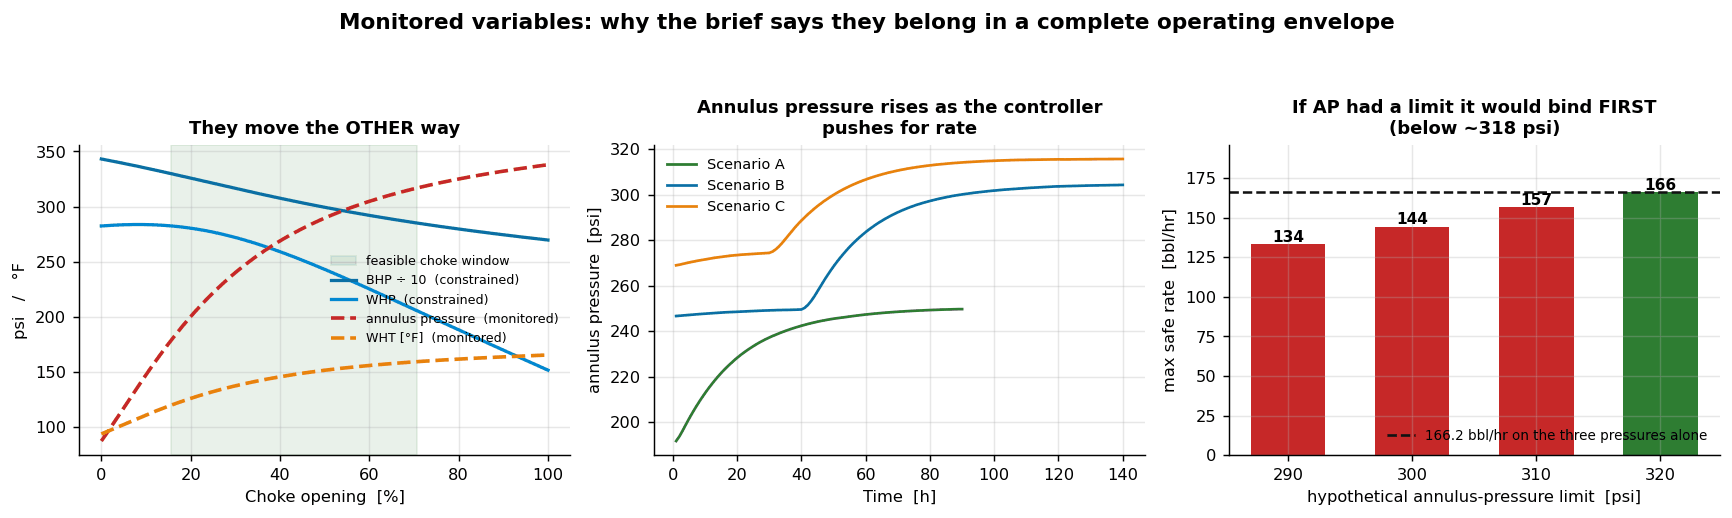

In [36]:
fig = plot_monitored({t: globals()[f"df{t}"] for t in "ABC"}, ENV); plt.show()

**The monitored variables move in the opposite direction to the constrained
ones.** Every choke opening that buys production relieves the pressure
constraints' upper ends while steadily raising a well-integrity risk that
nothing in the stated envelope is watching.

If annulus pressure had a limit anywhere below ~318 psi it would bind *before*
BHP — at 300 psi the well's safe capacity falls from 166 to 144 bbl/hr, a 13 %
difference driven entirely by an "informational" variable. Promoting either to a
hard constraint is a one-line change once an asset defines the limit: they are
already computed, logged and plotted.

---
## 14. Conclusions and lessons learned

### What the evidence supports

| Claim | Evidence |
|---|---|
| The control model is trustworthy | R² = 0.983 – 0.993 free-run on the Honeywell reference data, which it was never fitted to |
| The controller is safe | 0 violations in 30 nominal runs; 0 / 150 randomised models in Scenario B; 4.7 % in Scenario C with a worst excursion of 1.16 psi on a 2850 psi limit |
| It is worth having | Scenario C: PI violates on 69 % of intervals; the cautious operator gives up 5.6 % of production; the MPC gives up neither |
| It degrades safely | Survives 48 psi of unmodelled depletion, a 12 % water-cut step, a frozen transmitter and a two-tag IO-card failure |
| We know where it fails | Back-off 0 psi, noise ≥ 12× nominal, or τ_BHP under-estimated by more than ~30 % |
| The result does not depend on our invented limits | 0 violations across 200 randomised envelopes, reaching 96.9 % of each envelope's own ceiling, with the binding constraint shifting between WHP, BHP and FLP |

### Lessons learned

**1. Penalise every move in the plan, not just the first.**
Our first cost function suppressed only Δu₁. The optimiser learned to set
Δu₁ = 0 and let Δu₂ do the work at zero cost — and since a receding-horizon
controller only ever applies the first move, the controller stalled with a
3–7 bbl/hr steady-state offset. Penalising all moves removed it completely.
This was the single biggest bug in the project.

**2. We misdiagnosed our own controller, and the sweep caught it.**
We had recorded "the prediction horizon must cover the slowest constrained
variable" as a lesson, because violations disappeared when we lengthened P from
20 h to 40 h. Sweeping P from 5 h to 50 h properly (§12) shows that is **not**
what fixed it: with the SSTO guaranteeing a feasible endpoint, horizon length
only tightens the worst excursion from 0.77 to 0.23 psi and never causes a
violation on its own. What actually fixed it was the constraint back-off, which
we happened to change at the same time. The honest lesson is about method, not
horizons: **we changed two things at once and credited the wrong one.**

**3. A small constraint back-off buys a large safety margin, cheaply.**
At 0 psi: 13 violating intervals. At 1 psi: zero. We run 5 psi, which costs
1.2 bbl/hr (0.7 % of production) and holds up under 8× measurement noise.

**4. Diagnosing the failure mechanism beats blanket conservatism.**
Every mismatch failure had one cause — under-estimated τ_BHP. Knowing that, a
targeted fix (bias the identified τ of the slowest constrained variable upward
by 50 %) reaches zero violations for ~0.9 bbl/hr, where blind conservatism via a
12 psi back-off costs 3.9 bbl/hr for the same result.

**5. The safety margin is not slack — we tried to spend it and put it back.**
The fixed 5 psi back-off looks over-conservative when a narrow variable binds.
Making it proportional to each variable's span recovered 2.4 percentage points of
production and lost the zero-violation guarantee on 9 % of 200 randomised
envelopes. Knowing the price of a margin turned out to be worth more than shaving
it.

**6. Separating the steady-state and dynamic problems is what makes
infeasibility safe.**
Handling "target too high" inside a single MPC cost function causes wind-up. A
dedicated steady-state optimiser turns it into a clean, explainable answer:
here is the most you can safely have, and here is the limit stopping you.

**7. Constraint redundancy is real, and it changes what a fault test means.**
A single corrupted pressure transmitter did far less damage than expected,
because a second constraint on a healthy measurement was only 5 psi behind it.
The dangerous failure is the *correlated* one — a shared IO card — and a fault
study that only injects single-tag faults will overstate how safe the system is.

### How this extends to a real asset

* **Multi-well.** Replace the calibrated manifold correlation with a network
  model and add a shared separator-capacity constraint across wells.
* **Adaptive.** Schedule periodic re-identification for reservoir depletion and
  rising water cut, biasing τ conservatively on constrained variables (§11).
* **Economic layer.** Replace "track the rate target" in the SSTO with
  "maximise oil revenue minus water-handling cost" — same architecture.
* **Instrumentation.** The F4 result argues for constraint-critical measurements
  on independent IO paths, or a soft-sensor cross-check.
* **Promote WHT and annulus pressure** from monitored variables to hard
  constraints once integrity limits are defined for the asset.